# ChickenStress — Notebook Gabungan (Kaggle Edition)

**Sebelum Run All, pastikan:**
1. **Add Data** (sidebar kanan) — upload folder dataset lama kamu (yang isinya `train/`, `valid/`, `test/`, masing-masing dengan `_annotations.coco.json`) sebagai Kaggle Dataset, lalu attach ke notebook ini.
2. **Accelerator** — Settings → Accelerator → pilih GPU (T4 x2 / P100), supaya VLM (fine-tuning & inferensi) tidak jalan di CPU.
3. **Internet** — Settings → Internet → ON. Dibutuhkan untuk `pip install` dan mengunduh bobot VLM dari HuggingFace (`Qwen/Qwen3-VL-8B-Instruct`).


# Bagian 1 — Image Preprocessing
*(dari `01_image_processing.ipynb`)*

# ChickenStress — 01. Pemrosesan Data

Notebook ini adalah pecahan dari notebook eksplorasi awal:
1. **Dataset asli tidak disentuh** — semua proses membaca dari salinan kerja (`WORK_DIR`), bukan langsung dari folder sumber (`RAW_DIR`). Folder sumber hanya dibaca sekali untuk di-copy, tidak pernah ditulis ulang.
2. **Augmentasi & balancing hanya di train** — split train/valid dilakukan *sebelum* augmentasi, dan augmentasi/balancing hanya diterapkan ke folder `train`. Folder `valid` dan `test` tetap murni data asli.

# Beberapa Catatan
- **Bagian "Dataset deteksi format YOLO" dan debug anchor size DIHAPUS** — dulu dibutuhkan untuk melatih 3 detector (YOLOv11, DINOv2, EfficientNetV2 sebagai backbone `FasterRCNN`); sekarang tidak ada detector yang dilatih sama sekali (klasifikasi langsung di level crop oleh VLM), jadi bagian itu jadi output yang nganggur.
- **`RandomVerticalFlip` dihapus dari augmentasi** — checklist *Stressed Chicken Scale* menilai postur yang eksplisit relatif atas/bawah (ekor turun, kepala menunduk, sayap terkulai, kaki merunduk); membalik gambar secara vertikal membuat ayam terlihat "terbalik" (tidak realistis) dan justru membalik makna sinyal stresnya sendiri. Lihat detail di Section 5.
- **`DEST/test` sekarang diambil dari split `test` ASLI dataset (`RAW_DIR/test`)**, bukan dari re-split folder `train`. Sebelumnya `DEST/test` (hasil split 70/15/15 dari `train_df`) tidak pernah benar-benar dipakai untuk evaluasi model manapun (evaluasi lama memakai `yolo_detect_dataset/images/test` dari `RAW_DIR/test`) — kalau dibiarkan, `03_evaluate.ipynb` versi VLM akan salah menguji model pada data yang sebagian masih "sekeluarga" dengan data training, bukan benar-benar held-out. Lihat Section 6 (baru).
- Folder perantara `classification_dataset_raw` **dihapus dari pipeline** — crop bounding box dan split train/valid sekarang digabung jadi satu langkah, langsung menulis ke `WORK_DIR/dataset`.
- Ditambahkan **Quality Check** (RGB/non-RGB, file corrupt, mismatch ukuran metadata vs aktual, deteksi blur) sebelum data diproses lebih lanjut.


In [1]:
import os
import json
import random
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch

pd.set_option("display.max_columns", None)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Reproducibility seed set to", SEED)


Reproducibility seed set to 42


## 1. Lokasi Dataset

In [ ]:
import os

# auto-deteksi folder dataset yang di-upload lewat "Add Data" ====
# Kaggle me-mount dataset yang di-add di /kaggle/input/<nama-dataset>/, tapi struktur di
# dalamnya tergantung cara folder "Data" (berisi train/valid/test) di-zip sebelum diupload --
# bisa jadi /kaggle/input/<nama-dataset>/Data/train/... ATAU langsung
# /kaggle/input/<nama-dataset>/train/... . Kode di bawah mencari folder mana pun di bawah
# /kaggle/input yang punya subfolder train/valid/test, apa pun nama dataset/nesting-nya --
# supaya tidak perlu edit path manual tiap kali dataset diganti/di-upload ulang.

def find_raw_dir(search_root="/kaggle/input"):
    for dirpath, dirnames, filenames in os.walk(search_root):
        if {"train", "valid", "test"}.issubset(set(dirnames)):
            return dirpath
    return None

RAW_DIR = find_raw_dir()
if RAW_DIR is None:
    raise FileNotFoundError(
        "Tidak ketemu folder berisi subfolder train/valid/test di bawah /kaggle/input.\n"
        "Pastikan dataset sudah di-'Add Data' (sidebar kanan) dan ter-attach ke notebook ini,\n"
        "lalu jalankan ulang cell ini. Kalau strukturnya masih tidak ketemu, cek manual dengan:\n"
        "  !find /kaggle/input -maxdepth 4 -type d"
    )

WORK_DIR = "/kaggle/working/Data_working"  # semua hasil kerja (crop, augmentasi, checkpoint) ditulis di sini

RAW_TRAIN_DIR = os.path.join(RAW_DIR, "train")
RAW_VALID_DIR = os.path.join(RAW_DIR, "valid")
RAW_TEST_DIR  = os.path.join(RAW_DIR, "test")

TRAIN_DIR = os.path.join(WORK_DIR, "train")
VALID_DIR = os.path.join(WORK_DIR, "valid")
TEST_DIR  = os.path.join(WORK_DIR, "test")

print("RAW_DIR terdeteksi:", RAW_DIR)
print("WORK_DIR:", WORK_DIR)


RAW_DIR terdeteksi: /kaggle/input/datasets/argamasijabat/raw-data-chicken-stress/Data
WORK_DIR: /kaggle/working/Data_working


## 2. Copy dataset asli ke working folder

Dilakukan sekali saja (idempotent — kalau `WORK_DIR` sudah ada, tidak di-copy ulang). Setelah ini, **semua** cell berikutnya hanya membaca/menulis di `WORK_DIR`, tidak pernah menyentuh `RAW_DIR`.

In [3]:
def copy_raw_dataset(raw_dir, work_dir):
    if os.path.exists(work_dir):
        print(f"[SKIP] {work_dir} sudah ada, tidak meng-copy ulang (dataset asli tetap aman).")
        return

    print(f"Meng-copy dataset asli dari:\n  {raw_dir}\nke:\n  {work_dir}")
    shutil.copytree(raw_dir, work_dir)
    print("Selesai copy. Dataset asli tidak diubah sama sekali.")

copy_raw_dataset(RAW_DIR, WORK_DIR)


Meng-copy dataset asli dari:
  /kaggle/input/datasets/argamasijabat/raw-data-chicken-stress/Data
ke:
  /kaggle/working/Data_working
Selesai copy. Dataset asli tidak diubah sama sekali.


In [4]:
def load_coco(folder):

    json_path = os.path.join(folder, "_annotations.coco.json")

    with open(json_path, "r") as f:
        coco = json.load(f)

    images = pd.DataFrame(coco["images"])
    annotations = pd.DataFrame(coco["annotations"])
    categories = pd.DataFrame(coco["categories"])

    return images, annotations, categories


In [5]:
train_images, train_ann, categories = load_coco(TRAIN_DIR)
valid_images, valid_ann, _ = load_coco(VALID_DIR)
test_images, test_ann, _ = load_coco(TEST_DIR)


In [6]:
print(train_images.shape)
print(train_ann.shape)
print(categories.shape)

display(train_images.head())
display(train_ann.head())
display(categories)


(47, 7)
(111, 7)
(5, 3)


,id,license,file_name,height,width,date_captured,extra
0,0,1,hs01_jpeg.rf.853acf3a6190a72bed4a9811fa48e856.jpg,640,640,2026-07-20T06:37:39+00:00,{'name': 'hs01.jpeg'}
1,1,1,high-23-_jpg.rf.2c66ea904fb44ef9f692d935117c1e...,640,640,2026-07-20T06:37:39+00:00,{'name': 'high-23-.jpg'}
2,2,1,medium-3-_jpg.rf.e1ede1cff5e00c5e6d85994a4d8c0...,640,640,2026-07-20T06:37:39+00:00,{'name': 'medium-3-.jpg'}
3,3,1,s2_jpg.rf.23ec2682c71396c44b880237ae3f1ace.jpg,640,640,2026-07-20T06:37:39+00:00,{'name': 's2.jpg'}
4,4,1,s3_jpg.rf.0baa582ee2b5d7a62f8c71050fd23891.jpg,640,640,2026-07-20T06:37:39+00:00,{'name': 's3.jpg'}


,id,image_id,category_id,bbox,iscrowd,area,segmentation
0,1,0,1,"[130.75, 105.75, 309.5, 400.5]",0,123954.75,[]
1,2,1,1,"[100.5, 25.75, 306, 527.5]",0,161415.00,[]
2,3,1,1,"[320.25, 21, 85.5, 156]",0,13338.00,[]
3,4,2,3,"[191, 0, 250, 640]",0,160000.00,[]
4,5,2,3,"[190.25, 0.25, 88.5, 181.5]",0,16062.75,[]


,id,name,supercategory
0,0,normal-stressed,none
1,1,high_stress,normal-stressed
2,2,low_stress,normal-stressed
3,3,medium_stress,normal-stressed
4,4,normal,normal-stressed


In [7]:
label_map = dict(zip(categories.id, categories.name))
label_map

{0: 'normal-stressed',
 1: 'high_stress',
 2: 'low_stress',
 3: 'medium_stress',
 4: 'normal'}

In [ ]:
#  gabungkan train+valid+test JADI SATU POOL sebelum deteksi sesi & balancing & split. Ini WAJIB karena
# inspeksi data mentah menunjukkan:
#   - RAW_DIR/train : 47 gambar, 111 bbox -- HAMPIR SEMUA data (termasuk SEMUA stress) ada di sini
#   - RAW_DIR/valid : cuma 2 gambar, 3 bbox, SEMUA berlabel 'normal' (nol stress)
#   - RAW_DIR/test  : cuma 2 gambar, 5 bbox, SEMUA berlabel 'normal' (nol stress)
# Split bawaan Roboflow ini sepertinya didesain untuk keperluan lain (mis. deteksi objek YOLO,
# di mana valid/test sekecil itu masih lazim) -- kalau dipakai apa adanya di workflow VLM kita,
# DEST/test yang dihasilkan 100% 'not_stress', dan evaluasi model jadi TIDAK BISA mengukur
# kemampuan mendeteksi ayam stres sama sekali (support=0 untuk kelas 'stress'). Solusinya: satukan
# dulu semua bbox dari ketiga folder ke satu pool (`all_df`), baru kita split ULANG sendiri secara
# stratified per kelas biner di cell setelah deteksi sesi -- supaya train/valid/test hasil akhir
# semuanya kebagian proporsi 'stress' yang wajar.

def build_full_df(images_df, ann_df, source_dir, split_name):
    df = ann_df.copy()
    df["label"] = df["category_id"].map(label_map)
    df = df.merge(
        images_df[["id", "file_name", "width", "height"]],
        left_on="image_id", right_on="id", how="left"
    )
    df[["x", "y", "w", "h"]] = pd.DataFrame(df["bbox"].tolist(), index=df.index)
    df["bbox_area"] = df["w"] * df["h"]
    df["image_path"] = df["file_name"].apply(lambda fn: os.path.join(source_dir, fn))
    df["source_split"] = split_name  # PATCH: cuma catatan folder asal, TIDAK dipakai lagi sbg split final
    return df

train_part = build_full_df(train_images, train_ann, TRAIN_DIR, "train")
valid_part = build_full_df(valid_images, valid_ann, VALID_DIR, "valid")
test_part  = build_full_df(test_images, test_ann, TEST_DIR, "test")

all_df = pd.concat([train_part, valid_part, test_part], ignore_index=True)

print("Jumlah bbox per folder asal (SEBELUM digabung ulang -- cuma info, bukan split final):")
display(all_df["source_split"].value_counts())
print("\nJumlah bbox per kelas ASLI (4 kelas, gabungan ketiga folder):")
display(all_df["label"].value_counts())

all_df.head()


Jumlah bbox per folder asal (SEBELUM digabung ulang -- cuma info, bukan split final):


source_split
train    111
test       5
valid      3
Name: count, dtype: int64


Jumlah bbox per kelas ASLI (4 kelas, gabungan ketiga folder):


label
normal           56
medium_stress    28
high_stress      25
low_stress       10
Name: count, dtype: int64

,id_x,image_id,category_id,bbox,iscrowd,area,segmentation,label,id_y,file_name,width,height,x,y,w,h,bbox_area,image_path,source_split
0,1,0,1,"[130.75, 105.75, 309.5, 400.5]",0,123954.75,[],high_stress,0,hs01_jpeg.rf.853acf3a6190a72bed4a9811fa48e856.jpg,640,640,130.75,105.75,309.5,400.5,123954.75,/kaggle/working/Data_working/train/hs01_jpeg.r...,train
1,2,1,1,"[100.5, 25.75, 306, 527.5]",0,161415.00,[],high_stress,1,high-23-_jpg.rf.2c66ea904fb44ef9f692d935117c1e...,640,640,100.50,25.75,306.0,527.5,161415.00,/kaggle/working/Data_working/train/high-23-_jp...,train
2,3,1,1,"[320.25, 21, 85.5, 156]",0,13338.00,[],high_stress,1,high-23-_jpg.rf.2c66ea904fb44ef9f692d935117c1e...,640,640,320.25,21.00,85.5,156.0,13338.00,/kaggle/working/Data_working/train/high-23-_jp...,train
3,4,2,3,"[191, 0, 250, 640]",0,160000.00,[],medium_stress,2,medium-3-_jpg.rf.e1ede1cff5e00c5e6d85994a4d8c0...,640,640,191.00,0.00,250.0,640.0,160000.00,/kaggle/working/Data_working/train/medium-3-_j...,train
4,5,2,3,"[190.25, 0.25, 88.5, 181.5]",0,16062.75,[],medium_stress,2,medium-3-_jpg.rf.e1ede1cff5e00c5e6d85994a4d8c0...,640,640,190.25,0.25,88.5,181.5,16062.75,/kaggle/working/Data_working/train/medium-3-_j...,train


In [9]:
all_df.isnull().sum()


id_x            0
image_id        0
category_id     0
bbox            0
iscrowd         0
area            0
segmentation    0
label           0
id_y            0
file_name       0
width           0
height          0
x               0
y               0
w               0
h               0
bbox_area       0
image_path      0
source_split    0
dtype: int64

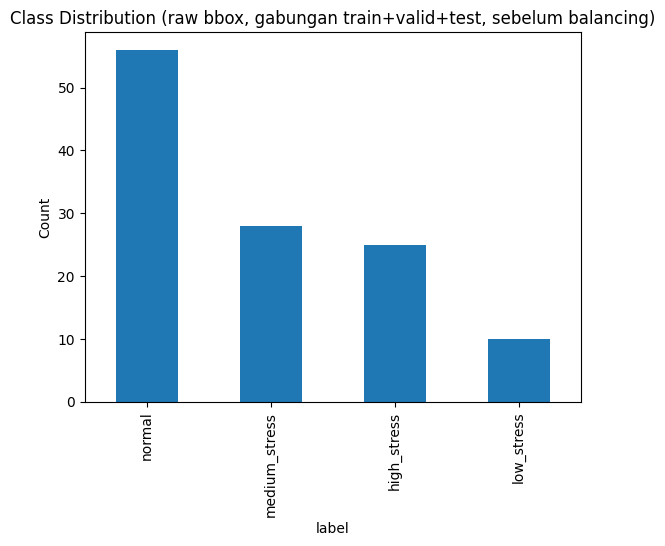

In [10]:
all_df["label"].value_counts()

all_df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution (raw bbox, gabungan train+valid+test, sebelum balancing)")
plt.ylabel("Count")
plt.show()


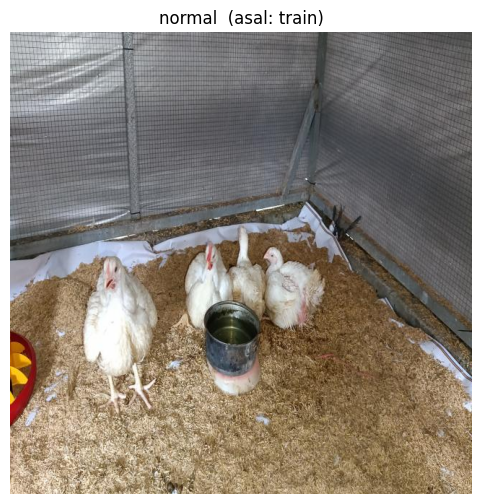

In [11]:
sample = all_df.sample(1).iloc[0]

img = Image.open(sample.image_path)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title(f"{sample.label}  (asal: {sample.source_split})")
plt.show()


## 3. Quality Check Gambar Mentah (RGB, ukuran, file rusak, blur)

Dicek di gambar **mentah** (`WORK_DIR/train`, `valid`, `test` — sebelum di-crop), supaya ketahuan dari awal kalau ada:
- File yang gagal/tidak bisa dibuka (corrupt)
- Gambar bukan RGB (misal grayscale/CMYK/RGBA) — ini tidak akan bikin pipeline crash karena langkah crop di bawah sudah pakai `.convert("RGB")`, tapi tetap penting diketahui (bisa indikasi sumber data campuran)
- **Mismatch ukuran**: lebar/tinggi aktual file vs yang tercatat di `_annotations.coco.json`. Ini penting karena crop (`img.crop((x, y, x+w, y+h))`) memakai koordinat bbox absolut dari metadata COCO langsung di atas gambar yang dibuka — kalau ukuran aktual file berbeda dari metadata saat anotasi dibuat, posisi crop yang dihasilkan bisa salah/bergeser tanpa ada error yang muncul
- Gambar yang kemungkinan blur (pakai variance of Laplacian — angka kecil = makin blur)

File yang corrupt di split `train` akan otomatis dikeluarkan dari `train_df` di cell berikutnya (supaya proses crop+split tidak crash), dengan print log yang jelas file mana yang dibuang.


In [12]:
def check_image_quality(images_df, folder, split_name):
    rows = []
    for _, r in images_df.iterrows():
        path = os.path.join(folder, r["file_name"])
        record = {
            "file_name": r["file_name"],
            "split": split_name,
            "meta_width": r.get("width"),
            "meta_height": r.get("height"),
        }
        try:
            img = Image.open(path)
            img.load()  # paksa baca seluruh file, supaya file truncated/corrupt ketahuan di sini
            record["corrupt"] = False
            record["mode"] = img.mode
            record["actual_width"], record["actual_height"] = img.size
            record["size_mismatch"] = (
                record["actual_width"] != record["meta_width"]
                or record["actual_height"] != record["meta_height"]
            )
            gray = np.array(img.convert("L"), dtype=np.float64)
            lap = (
                -4 * gray
                + np.roll(gray, 1, axis=0) + np.roll(gray, -1, axis=0)
                + np.roll(gray, 1, axis=1) + np.roll(gray, -1, axis=1)
            )
            record["laplacian_var"] = lap.var()
        except Exception as e:
            record.update({
                "corrupt": True, "mode": None,
                "actual_width": None, "actual_height": None,
                "size_mismatch": None, "laplacian_var": None,
                "error": str(e),
            })
        rows.append(record)
    return pd.DataFrame(rows)

quality_train = check_image_quality(train_images, TRAIN_DIR, "train")
quality_valid = check_image_quality(valid_images, VALID_DIR, "valid")
quality_test  = check_image_quality(test_images, TEST_DIR, "test")

quality_df = pd.concat([quality_train, quality_valid, quality_test], ignore_index=True)
print("Total gambar dicek:", len(quality_df))


Total gambar dicek: 51


In [13]:
# --- File corrupt ---
n_corrupt = int(quality_df["corrupt"].sum())
print(f"File corrupt/gagal dibuka: {n_corrupt}")
if n_corrupt > 0:
    display(quality_df.loc[quality_df["corrupt"], ["file_name", "split", "error"]])


File corrupt/gagal dibuka: 0


In [14]:
# --- Mode warna (RGB vs non-RGB) ---
print("Distribusi mode warna:")
display(quality_df["mode"].value_counts(dropna=False))

non_rgb = quality_df[(quality_df["mode"].notna()) & (quality_df["mode"] != "RGB")]
print(f"\nGambar non-RGB: {len(non_rgb)} dari {quality_df['mode'].notna().sum()} yang berhasil dibuka")
if len(non_rgb) > 0:
    display(non_rgb[["file_name", "split", "mode"]].head(20))


Distribusi mode warna:


mode
RGB    51
Name: count, dtype: int64


Gambar non-RGB: 0 dari 51 yang berhasil dibuka


In [15]:
# --- Mismatch ukuran: metadata COCO vs file aktual ---
mismatch = quality_df[quality_df["size_mismatch"] == True]
print(f"Gambar dengan ukuran aktual != metadata COCO: {len(mismatch)}")
if len(mismatch) > 0:
    display(mismatch[["file_name", "split", "meta_width", "meta_height", "actual_width", "actual_height"]].head(20))
    print("\n>> PERHATIAN: kalau ada baris di atas, hasil crop bounding box untuk file itu berpotensi salah posisi")
    print("   (koordinat bbox dianotasi berdasarkan meta_width/meta_height, bukan actual_width/actual_height) --")
    print("   cek manual dulu sebelum dipakai sebagai data training/evaluasi VLM.")


Gambar dengan ukuran aktual != metadata COCO: 0


Statistik ukuran aktual (width x height, px):


,actual_width,actual_height
count,51.0,51.0
mean,640.0,640.0
std,0.0,0.0
min,640.0,640.0
25%,640.0,640.0
50%,640.0,640.0
75%,640.0,640.0
max,640.0,640.0


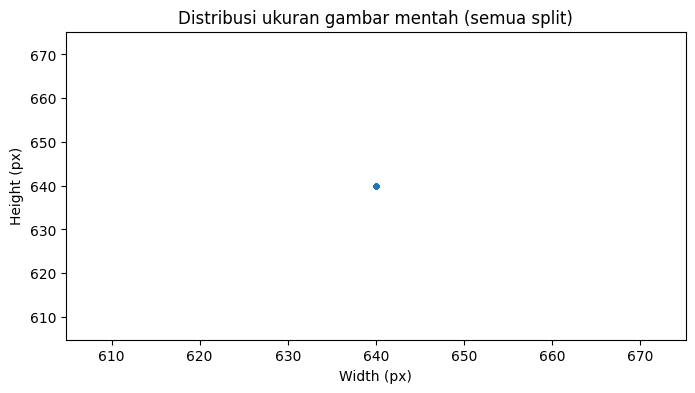

In [16]:
# --- Statistik ukuran gambar ---
print("Statistik ukuran aktual (width x height, px):")
display(quality_df[["actual_width", "actual_height"]].describe())

plt.figure(figsize=(8, 4))
plt.scatter(quality_df["actual_width"], quality_df["actual_height"], alpha=0.3, s=10)
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Distribusi ukuran gambar mentah (semua split)")
plt.show()


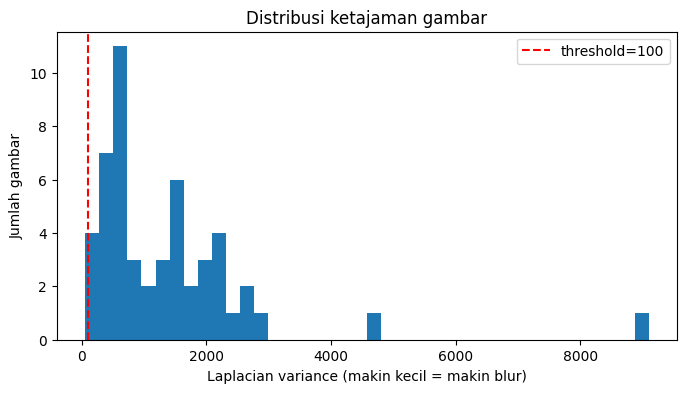

Gambar yang kemungkinan blur (Laplacian var < 100): 3 dari 51


,file_name,split,laplacian_var
4,s3_jpg.rf.0baa582ee2b5d7a62f8c71050fd23891.jpg,train,51.265327
14,73_NormalChicken_jpg.rf.8d50ceda103355d3d7bed4...,train,74.135522
48,IMG_-_-_jpg.rf.ac466c0d3196deb463c628abc21cf3f...,valid,77.398359



>> BLUR_THRESHOLD di atas cuma nilai awal umum, bukan hasil kalibrasi ke dataset ini.
   Cek dulu beberapa contoh gambar di 'blurry' secara visual, baru putuskan apakah mau dibuang atau tetap dipakai.


In [17]:
# --- Deteksi blur (variance of Laplacian) ---
BLUR_THRESHOLD = 100  # ambang umum yang sering dipakai; sesuaikan setelah lihat histogram di bawah

plt.figure(figsize=(8, 4))
plt.hist(quality_df["laplacian_var"].dropna(), bins=40)
plt.axvline(BLUR_THRESHOLD, color="red", linestyle="--", label=f"threshold={BLUR_THRESHOLD}")
plt.xlabel("Laplacian variance (makin kecil = makin blur)")
plt.ylabel("Jumlah gambar")
plt.legend()
plt.title("Distribusi ketajaman gambar")
plt.show()

blurry = quality_df[quality_df["laplacian_var"] < BLUR_THRESHOLD]
print(f"Gambar yang kemungkinan blur (Laplacian var < {BLUR_THRESHOLD}): "
      f"{len(blurry)} dari {quality_df['laplacian_var'].notna().sum()}")
display(blurry[["file_name", "split", "laplacian_var"]].sort_values("laplacian_var").head(20))
print("\n>> BLUR_THRESHOLD di atas cuma nilai awal umum, bukan hasil kalibrasi ke dataset ini.")
print("   Cek dulu beberapa contoh gambar di 'blurry' secara visual, baru putuskan apakah mau dibuang atau tetap dipakai.")


### Perbaikan Blur — Laplacian Sharpening (bukan langsung dibuang)

Alih-alih langsung membuang gambar yang terdeteksi blur, dicoba diperbaiki dulu pakai **Laplacian sharpening** (kernel penajam berbasis Laplacian) — konsisten dengan filosofi "perbaiki dulu, baru skip kalau masih buruk" di dokumen alur. `laplacian_var` di `quality_df` di-update dengan nilai setelah sharpening, supaya cell-cell berikutnya (termasuk keputusan buang/tidak) memakai kondisi gambar yang sudah diperbaiki.

In [18]:
# Kernel sharpening klasik = identity + Laplacian (menonjolkan tepi/detail yang hilang akibat blur)
SHARPEN_KERNEL = np.array([[0, -1, 0],
                            [-1, 5, -1],
                            [0, -1, 0]])

def laplacian_sharpen(img_bgr):
    return cv2.filter2D(img_bgr, -1, SHARPEN_KERNEL)

split_dirs = {"train": TRAIN_DIR, "valid": VALID_DIR, "test": TEST_DIR}
blurry_files = quality_df.loc[quality_df["laplacian_var"] < BLUR_THRESHOLD, ["file_name", "split", "laplacian_var"]]
print(f"Menerapkan Laplacian sharpening pada {len(blurry_files)} gambar yang terdeteksi blur...")

sharpen_log = []
for _, r in blurry_files.iterrows():
    path = os.path.join(split_dirs[r["split"]], r["file_name"])
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        continue  # file corrupt, sudah ditangani terpisah di cell berikutnya

    sharpened = laplacian_sharpen(img_bgr)
    lap_var_after = cv2.Laplacian(cv2.cvtColor(sharpened, cv2.COLOR_BGR2GRAY), cv2.CV_64F).var()

    cv2.imwrite(path, sharpened)  # PATCH: overwrite salinan kerja (WORK_DIR), RAW_DIR asli tidak disentuh

    sharpen_log.append({
        "file_name": r["file_name"], "split": r["split"],
        "laplacian_var_before": r["laplacian_var"], "laplacian_var_after": lap_var_after,
        "membaik": lap_var_after > r["laplacian_var"],
        "masih_dibawah_threshold": lap_var_after < BLUR_THRESHOLD,
    })

sharpen_log_df = pd.DataFrame(sharpen_log)
if len(sharpen_log_df):
    display(sharpen_log_df)
    n_improved = int(sharpen_log_df["membaik"].sum())
    n_still_blurry = int(sharpen_log_df["masih_dibawah_threshold"].sum())
    print(f"\nMembaik setelah sharpening: {n_improved} dari {len(sharpen_log_df)}")
    print(f"Masih di bawah threshold walau sudah di-sharpen: {n_still_blurry} "
          f"-- kandidat kuat untuk tetap dikeluarkan (lihat cell berikutnya)")

    # Update laplacian_var di quality_df dgn nilai TERBARU (setelah sharpening), supaya cell selanjutnya konsisten
    for _, row in sharpen_log_df.iterrows():
        mask = (quality_df["file_name"] == row["file_name"]) & (quality_df["split"] == row["split"])
        quality_df.loc[mask, "laplacian_var"] = row["laplacian_var_after"]

    SHARPEN_LOG_PATH = os.path.join(WORK_DIR, "blur_sharpening_log.csv")
    sharpen_log_df.to_csv(SHARPEN_LOG_PATH, index=False)
    print("Log sharpening disimpan ke:", SHARPEN_LOG_PATH)
else:
    print("Tidak ada gambar yang perlu di-sharpen.")

Menerapkan Laplacian sharpening pada 3 gambar yang terdeteksi blur...


,file_name,split,laplacian_var_before,laplacian_var_after,membaik,masih_dibawah_threshold
0,s3_jpg.rf.0baa582ee2b5d7a62f8c71050fd23891.jpg,train,51.265327,624.235987,True,False
1,73_NormalChicken_jpg.rf.8d50ceda103355d3d7bed4...,train,74.135522,864.736021,True,False
2,IMG_-_-_jpg.rf.ac466c0d3196deb463c628abc21cf3f...,valid,77.398359,808.942050,True,False



Membaik setelah sharpening: 3 dari 3
Masih di bawah threshold walau sudah di-sharpen: 0 -- kandidat kuat untuk tetap dikeluarkan (lihat cell berikutnya)
Log sharpening disimpan ke: /kaggle/working/Data_working/blur_sharpening_log.csv


In [ ]:
# --- Keluarkan file corrupt DAN yang masih blur walau sudah di-sharpen, dari SEMUA split ---
# sebelumnya hanya mengecek split=='train' (karena dulu cuma train_df yang dipakai).
# Sekarang all_df mencakup train+valid+test gabungan, jadi pengecekan dilakukan di semua split.
corrupt_pairs = set(map(tuple, quality_df.loc[quality_df["corrupt"], ["file_name", "split"]].values))

# laplacian_var di quality_df sudah di-update ke nilai SETELAH sharpening (cell sebelumnya),
still_blurry_pairs = set(map(tuple, quality_df.loc[
    (~quality_df["corrupt"]) & (quality_df["laplacian_var"] < BLUR_THRESHOLD),
    ["file_name", "split"],
].values))

exclude_pairs = corrupt_pairs | still_blurry_pairs

if exclude_pairs:
    before = len(all_df)
    mask = all_df.apply(lambda r: (r["file_name"], r["source_split"]) in exclude_pairs, axis=1)
    all_df = all_df[~mask].reset_index(drop=True)
    after = len(all_df)
    print(f"Dikeluarkan {before - after} baris anotasi dari all_df (gabungan train+valid+test):")
    if corrupt_pairs:
        print(f"  - corrupt/gagal dibuka ({len(corrupt_pairs)}):", sorted(corrupt_pairs))
    if still_blurry_pairs:
        print(f"  - masih blur walau sudah di-sharpen ({len(still_blurry_pairs)}):", sorted(still_blurry_pairs))
else:
    print("Tidak ada file corrupt atau masih-blur di seluruh split, all_df tidak diubah.")


Tidak ada file corrupt atau masih-blur di seluruh split, all_df tidak diubah.


## 3.5 Deteksi Sesi/Burst & Konsolidasi Label 4 → 2 Kelas (Balancing)


Analisis terhadap dataset asli (`Stressed_chicken_v19i_coco`) menunjukkan bukti konkret bahwa banyak citra berasal dari **sesi/burst capture yang sama** — bukan foto independen satu-satu seperti dugaan awal:
- Sebagian nama file memuat timestamp (`IMG_YYYYMMDD_HHMMSS`), dan beberapa berselisih **hanya beberapa detik** (jelas burst).
- Perceptual hashing (kemiripan visual) menemukan **~41% citra masuk cluster kemiripan tinggi** — termasuk 2 pasang yang identik 100% — terutama pada seri `high-N`, `medium-N`, `low-N` yang kemungkinan hasil ekstraksi frame berurutan.

Karena metadata `session_id`/`camera_id`/`kandang_id` asli **tidak tersedia** di `_annotations.coco.json`, `session_id` di bawah ini **dideteksi otomatis** dari data itu sendiri, dengan menggabungkan dua sinyal:
1. **Perceptual hashing (pHash)** — citra dengan kemiripan visual tinggi (hamming distance kecil) dikelompokkan sebagai sesi/burst yang sama.
2. **Timestamp dari nama file** (kalau ada, format `IMG_YYYYMMDD_HHMMSS`) — citra yang diambil berselisih pendek (≤ `SESSION_TIME_GAP_SEC`) digabung ke sesi yang sama, sebagai sinyal tambahan di luar kemiripan visual murni.

Hasil clustering ini dipakai sebagai `session_id` pengganti `file_name` untuk **balancing (undersampling seimbang)** dan **split train/val/test** — memastikan seluruh crop dari sesi/burst yang sama selalu berada di kelompok kelas & subset yang sama (tidak pernah tersebar), sesuai catatan no-leakage di dokumen alur.

**Prosedur balancing (tetap sama seperti sebelumnya, level unit-nya saja yang diperbaiki menjadi `session_id`):**
1. Ambil seluruh sesi berlabel dominan `normal` → hitung jumlahnya, sebut **N**.
2. Gabungkan seluruh sesi dari 3 kelas sisanya (`low_stress + medium_stress + high_stress`) menjadi satu pool kandidat `stress`.
3. Sampling **acak** dari pool tersebut sebanyak **N** sesi, proporsional/stratified terhadap `low_stress`, `medium_stress`, `high_stress`.
4. Hasil akhir: dataset biner seimbang di level sesi — `not_stress` (N sesi) vs `stress` (N sesi, campuran ketiga level).
5. Sisa sesi dari pool `stress` yang tidak terpakai **disimpan terpisah** (bukan dibuang).

> **Catatan jujur soal keterbatasan:** ini tetap heuristik (bukan `session_id` asli dari metadata pengambilan data), jadi ada kemungkinan kecil false-positive/negative pada clustering. Kalau nanti tersedia metadata sesi/video sesungguhnya, ganti langsung bagian *deteksi sesi* di bawah dengan kolom tersebut — bagian balancing & split setelahnya tidak perlu diubah karena sudah bekerja di level `session_id` generik.

**Tambahan** deteksi sesi/burst di bawah sekarang dijalankan di `all_df` (gabungan train+valid+test asli), bukan cuma `train_df`, karena split final sekarang dihitung ulang dari seluruh pool gabungan ini (lihat cell setelah deteksi sesi & balancing) -- ini yang memperbaiki masalah `DEST/test` yang sebelumnya 100% berisi kelas `not_stress`.

In [ ]:
# === Deteksi session_id/burst dari data itu sendiri (phash + timestamp nama file) ===
# Diperlukan supaya balancing & split di bawah tidak memecah crop dari sesi/burst yang sama
# ke kelompok kelas / subset yang berbeda (lihat catatan di markdown di atas).
# Dijalankan di `all_df` (gabungan train+valid+test), dan path gambar diambil per-file
# dari `all_df` langsung (bisa dari TRAIN_DIR/VALID_DIR/TEST_DIR tergantung folder asalnya),
# BUKAN lagi diasumsikan selalu ada di TRAIN_DIR.

import re
from datetime import datetime

try:
    import imagehash
except ImportError:
    %pip install -q imagehash
    import imagehash

SESSION_PHASH_THRESHOLD = 10   # hamming distance pHash <= ini dianggap sesi/burst yang sama
SESSION_TIME_GAP_SEC = 120     # kalau ada timestamp di nama file, gap <= ini (detik) juga digabung sesi

unique_files = all_df["file_name"].unique().tolist()
file_to_path = dict(zip(
    all_df.drop_duplicates("file_name")["file_name"],
    all_df.drop_duplicates("file_name")["image_path"],
))

# --- 1) Hitung pHash tiap citra unik ---
file_hash = {}
for fname in unique_files:
    file_hash[fname] = imagehash.phash(Image.open(file_to_path[fname]))

# --- 2) Ekstrak timestamp dari nama file (kalau ada pola IMG_YYYYMMDD_HHMMSS) ---
ts_pattern = re.compile(r"IMG_(\d{8})_(\d{6})")
file_timestamp = {}
for fname in unique_files:
    m = ts_pattern.search(fname)
    if m:
        file_timestamp[fname] = datetime.strptime(m.group(1) + m.group(2), "%Y%m%d%H%M%S")

# --- 3) Union-Find: gabungkan file yang (a) pHash mirip, ATAU (b) timestamp berdekatan ---
parent = {f: f for f in unique_files}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

for i in range(len(unique_files)):
    for j in range(i + 1, len(unique_files)):
        f1, f2 = unique_files[i], unique_files[j]
        merged = False
        if (file_hash[f1] - file_hash[f2]) <= SESSION_PHASH_THRESHOLD:
            merged = True
        if not merged and f1 in file_timestamp and f2 in file_timestamp:
            gap = abs((file_timestamp[f1] - file_timestamp[f2]).total_seconds())
            if gap <= SESSION_TIME_GAP_SEC:
                merged = True
        if merged:
            union(f1, f2)

# --- 4) Beri nama session_id yang rapi (session_0001, session_0002, ...) ---
roots = sorted(set(find(f) for f in unique_files))
root_to_session_id = {root: f"session_{i+1:04d}" for i, root in enumerate(roots)}
file_to_session = {f: root_to_session_id[find(f)] for f in unique_files}

all_df["session_id"] = all_df["file_name"].map(file_to_session)

session_sizes = all_df.drop_duplicates("file_name")["session_id"].value_counts()
n_multi_file_sessions = (session_sizes > 1).sum()
print(f"Total citra unik (gabungan train+valid+test): {len(unique_files)}")
print(f"Total session_id terdeteksi: {all_df['session_id'].nunique()}")
print(f"Sesi berisi >1 citra (burst terdeteksi): {n_multi_file_sessions}")
print(f"Threshold pHash <= {SESSION_PHASH_THRESHOLD}, gap timestamp <= {SESSION_TIME_GAP_SEC} detik")

session_map_df = (
    all_df.drop_duplicates("file_name")[["file_name", "source_split", "session_id"]]
    .sort_values("session_id")
    .reset_index(drop=True)
)
display(session_map_df.head(20))

SESSION_MAP_PATH = os.path.join(WORK_DIR, "session_id_mapping.csv")
session_map_df.to_csv(SESSION_MAP_PATH, index=False)
print("Mapping file_name -> session_id disimpan ke:", SESSION_MAP_PATH)


Total citra unik (gabungan train+valid+test): 51
Total session_id terdeteksi: 32
Sesi berisi >1 citra (burst terdeteksi): 12
Threshold pHash <= 10, gap timestamp <= 120 detik


,file_name,source_split,session_id
0,73_NormalChicken_jpg.rf.8d50ceda103355d3d7bed4...,train,session_0001
1,IMG_-_-_jpg.rf.ac466c0d3196deb463c628abc21cf3f...,valid,session_0002
2,IMG_20250511_135123_jpg.rf.5a13604cc8ccf1f72e3...,train,session_0003
3,IMG_20250511_135019_jpg.rf.ff32e28ebe8ff7f447f...,train,session_0003
4,IMG_20250511_140154_jpg.rf.d692a8a6d8488cc873c...,train,session_0004
5,IMG_20250511_135949_jpg.rf.e5ccd5e52968fcd05e1...,train,session_0004
6,IMG_20250511_140105_jpg.rf.9d14fca27731cf6972d...,train,session_0004
7,IMG_20250511_184231_jpg.rf.a790b8da17642b061e8...,valid,session_0005
8,IMG_20250511_185052_jpg.rf.74f4b8cc4aac1a728ff...,train,session_0006
9,IMG_20250511_185049_jpg.rf.7a0c68f7eefd524bb2d...,train,session_0006


Mapping file_name -> session_id disimpan ke: /kaggle/working/Data_working/session_id_mapping.csv


In [ ]:
# === Konsolidasi label 4 kelas -> 2 kelas biner  (JANGAN buang data stress) ===
# Versi sebelumnya melakukan undersampling: sesi 'stress' surplus DIBUANG supaya jumlahnya sama
# persis dengan sesi 'normal' (waktu itu 9 vs 9, membuang 10 sesi stress asli yang justru paling langka & berharga di dataset ini). Sekarang SEMUA sesi (normal maupun ketiga level stress)
# dipakai apa adanya -- ketidakseimbangan kelas di train ditangani lewat augmentasi (Section 5 di bawah, logikanya tidak berubah), bukan dengan membuang data mentah yang sudah sangat terbatas.

BINARY_MAP = {
    "normal": "not_stress",
    "low_stress": "stress",
    "medium_stress": "stress",
    "high_stress": "stress",
}

def to_binary_label(orig_label):
    # fallback aman: apa pun selain 'normal' dianggap 'stress'
    return BINARY_MAP.get(orig_label, "stress")

all_df["label_orig"] = all_df["label"]  # simpan label 4-kelas asli untuk referensi/log
all_df["label_stres_binary"] = all_df["label_orig"].map(to_binary_label)

# Label dominan per session_id (4-kelas) -- dipakai supaya SEMUA bbox dalam 1 sesi/burst yang sama
# konsisten dianggap 1 kelas biner yang sama saat split (no-leakage), bukan tercampur per-bbox.
def _dominant_nonstress_free_label(labels):
    labels = list(labels)
    if set(labels) == {"normal"}:
        return "normal"
    non_normal = [l for l in labels if l != "normal"]
    return pd.Series(non_normal).mode().iat[0]

session_dominant_label = all_df.groupby("session_id")["label_orig"].agg(_dominant_nonstress_free_label)
session_dominant_binary = session_dominant_label.map(to_binary_label)

print("Distribusi sesi per label ASLI (4 kelas, gabungan train+valid+test):")
display(session_dominant_label.value_counts())
print("\nDistribusi sesi per label BINER (setelah konsolidasi, TIDAK ADA yang dibuang):")
display(session_dominant_binary.value_counts())

# Label biner FINAL per baris/bbox = label dominan sesi-nya (konsisten se-sesi, no-leakage)
all_df["label"] = all_df["session_id"].map(session_dominant_binary)

print("\nDistribusi akhir (biner, SELURUH data gabungan, sebelum split 70/15/15):")
display(all_df["label"].value_counts())

# class_to_id/id_to_class dipindah ke sini (sebelumnya baru didefinisikan belakangan di Section 6 lama yang sekarang sudah dihapus -- lihat cell split+crop 3-arah di bawah).
class_names_sorted = ["not_stress", "stress"]
class_to_id = {name: i for i, name in enumerate(class_names_sorted)}
id_to_class = {i: name for name, i in class_to_id.items()}
print("\nclass_to_id:", class_to_id)

# Log referensi (bukan lagi "balancing log" karena tidak ada yang dibuang -- cuma catatan mapping)
balancing_log_df = pd.DataFrame({
    "session_id": session_dominant_label.index,
    "label_orig_dominant": session_dominant_label.values,
    "label_biner": session_dominant_binary.values,
}).sort_values("session_id").reset_index(drop=True)
BALANCING_LOG_PATH = os.path.join(WORK_DIR, "label_balancing_log.csv")
balancing_log_df.to_csv(BALANCING_LOG_PATH, index=False)
print("\nLog label per sesi (tidak ada yang dibuang) disimpan ke:", BALANCING_LOG_PATH)


Distribusi sesi per label ASLI (4 kelas, gabungan train+valid+test):


label_orig
normal           13
medium_stress     9
high_stress       7
low_stress        3
Name: count, dtype: int64


Distribusi sesi per label BINER (setelah konsolidasi, TIDAK ADA yang dibuang):


label_orig
stress        19
not_stress    13
Name: count, dtype: int64


Distribusi akhir (biner, SELURUH data gabungan, sebelum split 70/15/15):


label
stress        71
not_stress    48
Name: count, dtype: int64


class_to_id: {'not_stress': 0, 'stress': 1}

Log label per sesi (tidak ada yang dibuang) disimpan ke: /kaggle/working/Data_working/label_balancing_log.csv


In [ ]:
# (integrasi anotasi manual 7-indikator SCS): hitung `instance_key` per bbox menggabungkan box badan + box kepala yang sama-sama menunjuk ke satu ekor ayam yang sama jadi
# SATU instance -- persis dengan algoritma yang dipakai saat anotasi manual (indicators_ground_truth_multi.csv) dibuat, supaya bisa di-join dengan aman. Instance_key HARUS dihitung dari data + urutan
# yang identik (bbox_area menurun, digabung kalau overlap > 50% DAN kategori 4-kelas ASLI sama) -- lihat verifikasi join 69/69 cocok sebelum patch ini ditulis.
#
# Anotasi manual dibuat lewat tool terpisah (notebook "SCS Indicator Labeling Tool -- Multi-Chicken Edition") yang membaca _annotations.coco.json mentah yang SAMA dengan yang dipakai di sini.
#
MANUAL_ANNOTATION_CSV = "/kaggle/input/datasets/argamasijabat/chicken-stress-manual-annotation/indicators_ground_truth_multi.csv"

OVERLAP_THRESHOLD_INSTANCE = 0.5
INDICATOR_KEYS = [
    "posisi_ekor", "posisi_kepala", "penutupan_mata", "pembukaan_paruh",
    "posisi_sayap", "postur_kaki", "kondisi_bulu",
]  # PATCH: didefinisikan literal di sini (bukan dari SCS_INDICATORS) karena cell ini jalan di
   # Bagian 1, SEBELUM SCS_INDICATORS didefinisikan di Bagian 2 -- keys harus identik dgn kolom CSV.


def _box_xyxy(row):
    return row.x, row.y, row.x + row.w, row.y + row.h


def _overlap_ratio(small_row, big_row):
    sx1, sy1, sx2, sy2 = _box_xyxy(small_row)
    bx1, by1, bx2, by2 = _box_xyxy(big_row)
    ix1, iy1 = max(sx1, bx1), max(sy1, by1)
    ix2, iy2 = min(sx2, bx2), min(sy2, by2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    small_area = max(1e-6, (sx2 - sx1) * (sy2 - sy1))
    return inter / small_area


def assign_instance_keys(df):
    """Gabungkan box badan+kepala per ekor ayam jadi satu instance_key `split/file_name#instN`,
    dengan urutan & aturan overlap PERSIS SAMA seperti saat anotasi manual dibuat."""
    df = df.copy()
    df["instance_key"] = None
    for (split_name, fname), gdf in df.groupby(["source_split", "file_name"]):
        rows_sorted = gdf.sort_values("bbox_area", ascending=False)
        idx_list = rows_sorted.index.tolist()
        used = set()
        inst_n = 0
        for i, idx_a in enumerate(idx_list):
            if idx_a in used:
                continue
            used.add(idx_a)
            key = f"{split_name}/{fname}#inst{inst_n}"
            df.loc[idx_a, "instance_key"] = key
            row_a = rows_sorted.loc[idx_a]
            for idx_b in idx_list[i + 1:]:
                if idx_b in used:
                    continue
                row_b = rows_sorted.loc[idx_b]
                if row_b["label_orig"] == row_a["label_orig"] and _overlap_ratio(row_b, row_a) > OVERLAP_THRESHOLD_INSTANCE:
                    used.add(idx_b)
                    df.loc[idx_b, "instance_key"] = key
            inst_n += 1
    return df


all_df = assign_instance_keys(all_df)
print("Contoh instance_key:", all_df["instance_key"].dropna().unique()[:5].tolist())

if os.path.exists(MANUAL_ANNOTATION_CSV):
    manual_df = pd.read_csv(MANUAL_ANNOTATION_CSV)
    manual_df = manual_df[manual_df["excluded"] == 0].copy()
    manual_lookup = {}
    for _, r in manual_df.iterrows():
        manual_lookup[r["instance_key"]] = {
            "indicators": {k: str(r[k]) for k in INDICATOR_KEYS},
            "label_final": r["label_final"],
        }
    all_df["has_manual_annotation"] = all_df["instance_key"].isin(manual_lookup.keys())
    n_matched = int(all_df["has_manual_annotation"].sum())
    print(f"Anotasi manual dimuat: {len(manual_lookup)} instance berlabel "
          f"(setelah buang yang excluded=1), {n_matched} baris all_df berhasil dicocokkan.")
    if n_matched == 0:
        print("[!] TIDAK ADA yang cocok -- cek lagi apakah instance_key konsisten "
              "(kemungkinan versi data mentah beda dari saat CSV manual dibuat).")
else:
    manual_lookup = {}
    all_df["has_manual_annotation"] = False
    print(f"[!] File anotasi manual tidak ditemukan di: {MANUAL_ANNOTATION_CSV}")
    print("    Lanjut TANPA anotasi manual -- semua target training akan pakai template lama "
          "(fallback dari label biner). Cek lagi path attach dataset CSV-nya di Kaggle.")


Contoh instance_key: ['train/hs01_jpeg.rf.853acf3a6190a72bed4a9811fa48e856.jpg#inst0', 'train/high-23-_jpg.rf.2c66ea904fb44ef9f692d935117c1e4a.jpg#inst0', 'train/medium-3-_jpg.rf.e1ede1cff5e00c5e6d85994a4d8c00d9.jpg#inst0', 'train/s2_jpg.rf.23ec2682c71396c44b880237ae3f1ace.jpg#inst0', 'train/s3_jpg.rf.0baa582ee2b5d7a62f8c71050fd23891.jpg#inst0']
Anotasi manual dimuat: 69 instance berlabel (setelah buang yang excluded=1), 119 baris all_df berhasil dicocokkan.


## 4. Crop bounding box + split train/valid/test — level `session_id` (3-arah, no-leakage)

Split dilakukan di level **`session_id`** (hasil deteksi sesi/burst di atas), bukan di level index anotasi
individual — supaya seluruh crop dari sesi/burst yang sama selalu jatuh ke subset (train/valid/test) yang sama.

Split sekarang **3 arah (train/valid/test, 70/15/15)**, stratified per kelas biner, dijalankan dari **pool gabungan** (`all_df` = train+valid+test asli), BUKAN lagi 2 arah (train/valid) dengan `test` diambil terpisah dari `RAW_DIR/test` bawaan Roboflow — karena `RAW_DIR/test`(dan `RAW_DIR/valid`) ternyata cuma berisi 2 gambar dan 100% kelas `normal` (nol `stress`), sehingga evaluasi sebelumnya tidak pernah benar-benar menguji kemampuan mendeteksi ayam stres sama sekali. Section 6 (crop test set dari `RAW_DIR/test` terpisah) yang lama sudah **dihapus** karena tidak diperlukan lagi — semuanya sekarang ditangani dalam satu loop crop+split di bawah.


In [ ]:
from sklearn.model_selection import train_test_split

DEST = os.path.join(WORK_DIR, "dataset")
if os.path.exists(DEST):
    shutil.rmtree(DEST)

classes = sorted(all_df["label"].unique())
for split in ["train", "valid", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(DEST, split, cls), exist_ok=True)

random.seed(SEED)

def safe_group_split(items, test_size, random_state):
    """Fallback aman kalau jumlah sesi di suatu kelas terlalu sedikit untuk displit
    (train_test_split butuh minimal 2 anggota). Kalau tidak cukup, semua masuk kelompok pertama
    -- lebih baik daripada error atau leakage diam-diam."""
    if len(items) < 2:
        return items, []
    return train_test_split(items, test_size=test_size, random_state=random_state)

def stratified_three_way_split(items, valid_frac=0.15, test_frac=0.15, random_state=SEED):
    """PATCH v2 (poin 1): split 70/15/15 dihitung SENDIRI di sini per kelas biner, dari POOL
    GABUNGAN (all_df = train+valid+test asli) -- bukan lagi memakai folder 'test' bawaan Roboflow
    yang cuma 2 gambar & 100% 'normal'. Dilakukan bertahap: pisahkan test dulu, sisanya dibagi
    train/valid sesuai proporsi relatifnya."""
    items = list(items)
    if len(items) == 0:
        return [], [], []
    trainvalid, test = safe_group_split(items, test_size=test_frac, random_state=random_state)
    if len(test) == 0 and len(items) >= 2:
        print(f"  [!] Kelas dengan {len(items)} sesi -- tidak cukup untuk kebagian split 'test' juga.")
    if len(trainvalid) < 2:
        return trainvalid, [], test
    relative_valid = valid_frac / (1 - test_frac)
    train, valid = safe_group_split(trainvalid, test_size=relative_valid, random_state=random_state)
    return train, valid, test

session_label = all_df.drop_duplicates("session_id").set_index("session_id")["label"]

split_assignment_session = {}
for cls in classes:
    cls_sessions = session_label.index[session_label == cls].tolist()
    train_sess, valid_sess, test_sess = stratified_three_way_split(cls_sessions)
    print(f"Kelas '{cls}': {len(cls_sessions)} sesi -> "
          f"train={len(train_sess)}  valid={len(valid_sess)}  test={len(test_sess)}")
    for s in train_sess:
        split_assignment_session[s] = "train"
    for s in valid_sess:
        split_assignment_session[s] = "valid"
    for s in test_sess:
        split_assignment_session[s] = "test"

# Verifikasi: tiap session_id yang dipakai sudah punya assignment split (tidak ada yang terlewat)
assert all_df["session_id"].map(split_assignment_session).notna().all(), "Ada session_id tanpa assignment split!"

# (Jaminan minimal 1 instance tiap kelas di TEST evaluasi final): split di atas cuma stratifikasi per label BINER sesi (not_stress/stress) -- kelas 'undefined' (dari anotasi manual)
# tidak pernah jadi pertimbangan. Di sini: hitung label EFEKTIF per instance (label_final manual kalau ada, else label biner sesi),
# lalu kalau test belum punya minimal 1 instance utk salah satu dari 3 kelas, paksa pindahkan
# SATU session (utuh, supaya tidak memecah session yang sama ke split berbeda) dari train/valid ke test.
rep_df = all_df.sort_values("bbox_area", ascending=False).drop_duplicates("instance_key")
rep_df = rep_df.assign(effective_label=rep_df.apply(
    lambda r: manual_lookup.get(r["instance_key"], {}).get("label_final", r["label"]), axis=1
))

TARGET_TEST_CLASSES = ["not_stress", "stress", "undefined"]
for target in TARGET_TEST_CLASSES:
    test_sessions = {s for s, sp in split_assignment_session.items() if sp == "test"}
    present = set(rep_df.loc[rep_df["session_id"].isin(test_sessions), "effective_label"])
    if target in present:
        continue
    candidates = sorted(set(rep_df.loc[rep_df["effective_label"] == target, "session_id"]) - test_sessions)
    if not candidates:
        print(f"[!] Tidak ada instance ber-label '{target}' di seluruh dataset -- tidak bisa dipaksa masuk test.")
        continue
    chosen = candidates[0]
    old_split = split_assignment_session[chosen]
    split_assignment_session[chosen] = "test"
    print(f"Paksa pindahkan session '{chosen}' ({old_split} -> test) supaya kelas '{target}' terwakili di evaluasi final.")



# (FIX: crop sub-box kepala tidak lagi jadi training image terpisah): hanya box REPRESENTATIF (terbesar) per instance_key yang di-crop -- satu ekor ayam = satu training image.
# Augmentasi lain (blur/sharpen utk balancing, di cell setelah ini) TIDAK diubah.
all_df["_is_rep_box"] = all_df.groupby("instance_key")["bbox_area"].transform("max") == all_df["bbox_area"]
n_skipped_subbox = int((~all_df["_is_rep_box"]).sum())
print(f"Skip {n_skipped_subbox} box non-representatif (sub-box kepala) -- tidak di-crop jadi training image.")

counter_by_split_cls = {}
total_counter = {}
manual_target_lookup = {}  # PATCH v3: path crop -> anotasi manual asli (kalau ada)
n_crop_manual, n_crop_template = 0, 0
for idx, row in all_df[all_df["_is_rep_box"]].iterrows():
    split_name = split_assignment_session[row.session_id]

    # buka dari row.image_path masing-masing (bisa dari TRAIN_DIR/VALID_DIR/TEST_DIR
    # tergantung folder asal aslinya di RAW_DIR), BUKAN lagi diasumsikan selalu di satu folder tetap.
    img = Image.open(row.image_path).convert("RGB")
    x, y, w, h = int(row.x), int(row.y), int(row.w), int(row.h)
    crop = img.crop((x, y, x + w, y + h))

    cls = row.label
    key = (split_name, cls)
    counter_by_split_cls.setdefault(key, 0)
    counter_by_split_cls[key] += 1
    total_counter.setdefault(cls, 0)
    total_counter[cls] += 1

    filename = f"{cls}_{counter_by_split_cls[key]:04d}.jpg"
    crop_path = os.path.join(DEST, split_name, cls, filename)
    crop.save(crop_path)

    # kalau bbox ini (lewat instance_key) punya anotasi manual asli, catat supaya
    # nanti dipakai sebagai target fine-tuning -- bukan template dari label biner.
    if row.get("has_manual_annotation", False):
        manual_target_lookup[crop_path] = manual_lookup[row["instance_key"]]
        n_crop_manual += 1
    else:
        n_crop_template += 1

print("\nCrop + split 3-arah (level session_id, dari POOL GABUNGAN train+valid+test) selesai, langsung ke:", DEST)
print("Total crop per kelas (semua split):", total_counter)

# Distribusi crop per split x kelas (jumlah crop, bukan jumlah sesi)
split_counts = (
    all_df.assign(split=all_df["session_id"].map(split_assignment_session))
    .groupby(["split", "label"]).size()
)
display(split_counts)

print(f"\nCrop dengan anotasi manual asli (7 indikator): {n_crop_manual}")
print(f"Crop TANPA anotasi manual (fallback ke template dari label biner): {n_crop_template}")


Kelas 'not_stress': 13 sesi -> train=9  valid=2  test=2
Kelas 'stress': 19 sesi -> train=13  valid=3  test=3
Paksa pindahkan session 'session_0002' (train -> test) supaya kelas 'not_stress' terwakili di evaluasi final.
Skip 50 box non-representatif (sub-box kepala) -- tidak di-crop jadi training image.

Crop + split 3-arah (level session_id, dari POOL GABUNGAN train+valid+test) selesai, langsung ke: /kaggle/working/Data_working/dataset
Total crop per kelas (semua split): {'stress': 41, 'not_stress': 28}


split  label     
test   not_stress     6
       stress         8
train  not_stress    38
       stress        49
valid  not_stress     4
       stress        14
dtype: int64


Crop dengan anotasi manual asli (7 indikator): 69
Crop TANPA anotasi manual (fallback ke template dari label biner): 0


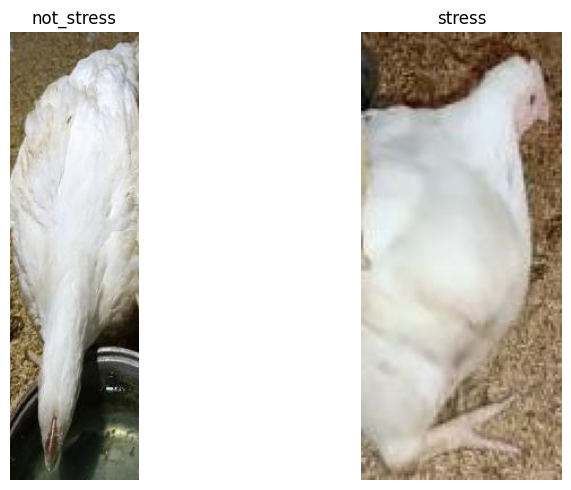

In [24]:
# Sample hasil crop per kelas (ambil dari dataset/train)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))  # PATCH: 2 kelas biner (not_stress/stress), bukan 4

for a, cls in zip(ax.flatten(), classes):
    cls_folder = os.path.join(DEST, "train", cls)
    img_name = random.choice(os.listdir(cls_folder))
    img = Image.open(os.path.join(cls_folder, img_name))
    a.imshow(img)
    a.set_title(cls)
    a.axis("off")

plt.tight_layout()
save_path = os.path.join(WORK_DIR, "sample_crop_classes.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
from torchvision import transforms

#  RandomVerticalFlip DIHAPUS dari augmentasi.
# Checklist Stressed Chicken Scale menilai postur yang secara eksplisit relatif atas/bawah
# (posisi ekor turun, kepala menunduk, sayap terkulai, postur kaki merunduk). Membalik gambar
# secara vertikal membuat ayam terlihat "terbalik" (tidak pernah terjadi di foto nyata kandang)
# DAN justru membalik makna sinyal stresnya sendiri -- ekor yang tadinya "turun" (stres) jadi
# terlihat seperti "naik" (tidak stres) di gambar hasil flip, tapi labelnya tetap sama di folder.
# Itu memberi contoh yang bertentangan dengan rule SCS ke model. Derajat rotasi juga diperkecil
# (20 -> 10, 15 -> 10) supaya postur relatif atas/bawah tidak banyak berubah.
augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
])


In [26]:
train_class_counts = {
    cls: len(os.listdir(os.path.join(DEST, "train", cls)))
    for cls in os.listdir(os.path.join(DEST, "train"))
}
TARGET = max(train_class_counts.values())

print(pd.Series(train_class_counts))
print("TARGET per kelas (train):", TARGET)


not_stress    23
stress        29
dtype: int64
TARGET per kelas (train): 29


## 5. Balancing — hanya folder `train`

Loop augmentasi membaca dan menulis ke `DEST/train/<kelas>` saja. `valid` dan `test` tidak pernah jadi target di loop ini.

In [27]:
for cls in train_class_counts:

    folder = os.path.join(DEST, "train", cls)  # <-- hanya train
    images_in_folder = os.listdir(folder)
    need = TARGET - len(images_in_folder)

    print(cls, "perlu tambahan:", need)

    for i in range(need):

        img_name = random.choice(images_in_folder)

        img = Image.open(os.path.join(folder, img_name)).convert("RGB")

        aug = augment(img)

        aug.save(os.path.join(folder, f"aug_{i}_{img_name}"))


not_stress perlu tambahan: 6
stress perlu tambahan: 0


In [28]:
def count_split(split):
    folder = os.path.join(DEST, split)
    return {cls: len(os.listdir(os.path.join(folder, cls))) for cls in os.listdir(folder)}

print("Train (setelah balancing):")
display(pd.Series(count_split("train")))

print("\nValid (tidak diaugmentasi):")
display(pd.Series(count_split("valid")))

print("\nTest (tidak diaugmentasi):")
display(pd.Series(count_split("test")))

print("\n✅ valid & test tidak pernah disentuh oleh loop augmentasi/balancing di atas.")


Train (setelah balancing):


not_stress    29
stress        29
dtype: int64


Valid (tidak diaugmentasi):


not_stress    2
stress        7
dtype: int64


Test (tidak diaugmentasi):


not_stress    3
stress        5
dtype: int64


✅ valid & test tidak pernah disentuh oleh loop augmentasi/balancing di atas.


## 6. Simpan artefak untuk bagian selanjutnya 

Menyimpan semua path (`WORK_DIR`, `DEST`, dll.), mapping kelas (`label_map`, `class_to_id`, `id_to_class`),
dan dataframe gabungan (`all_df`, sudah berisi kolom `session_id` + `label` biner final) ke satu file pickle.
Bagian 2/3 di bawah memuat file ini kalau dijalankan sebagai notebook terpisah (di notebook gabungan ini,
variabelnya sudah langsung tersedia di memori).

`train_df`/`valid_df`/`test_df` terpisah **dihapus** dari artefak -- sudah tidak relevan lagi
karena split final sekarang dihitung ulang dari `all_df` (pool gabungan train+valid+test asli), bukan dari
ketiganya secara terpisah seperti sebelumnya.


In [29]:
import pickle

artifact_state = {
    "RAW_DIR": RAW_DIR, "WORK_DIR": WORK_DIR,
    "RAW_TRAIN_DIR": RAW_TRAIN_DIR, "RAW_VALID_DIR": RAW_VALID_DIR, "RAW_TEST_DIR": RAW_TEST_DIR,
    "TRAIN_DIR": TRAIN_DIR, "VALID_DIR": VALID_DIR, "TEST_DIR": TEST_DIR,
    "DEST": DEST,
    "label_map": label_map, "class_to_id": class_to_id, "id_to_class": id_to_class,
    "class_names_sorted": class_names_sorted,
    "all_df": all_df,  # PATCH v2: gabungan train+valid+test asli + session_id + label biner final,
                        # menggantikan train_df/valid_df/test_df terpisah dari versi sebelumnya.
}

ARTIFACT_PATH = os.path.join(WORK_DIR, "pipeline_artifacts.pkl")
with open(ARTIFACT_PATH, "wb") as f:
    pickle.dump(artifact_state, f)

print("Artefak notebook 1 disimpan ke:", ARTIFACT_PATH)
print("Notebook 2 (models) dan notebook 3 (evaluate) akan memuat file ini di awal.")


Artefak notebook 1 disimpan ke: /kaggle/working/Data_working/pipeline_artifacts.pkl
Notebook 2 (models) dan notebook 3 (evaluate) akan memuat file ini di awal.


# Bagian 2 — Use & Train VLM

# ChickenStress — 02. Use & Train VLM (Vision-Language Model)

**(Workflow Change  — Project AgroNova AI):** notebook ini menggantikan seluruh isi lama `02_models.ipynb`
(6 konfigurasi CNN/detector: YOLOv11, DINOv2, EfficientNetV2, train-from-scratch).

Alasan perubahan :
- Data sangat terbatas (±30–40 gambar) — model classic (CNN train-from-scratch) butuh data jauh lebih banyak
  untuk training & evaluasi yang valid, risiko overfit/tidak reliabel.
- Workflow baru memanfaatkan **VLM (Vision-Language Model)** yang sudah punya pengetahuan visual luas,
  jadi lebih tahan terhadap keterbatasan jumlah data (*use & train*, bukan train from scratch).

**Alur baru :**
`Image Dataset → Image Preprocessing → Use & Train VLM → Classification → Evaluation`

Dataset, crop, split train/valid/test — dipertahankan sebagai *Image Preprocessing*, lalu mengerjakan tahap **Use & Train VLM** + **Classification**:
1. **Rules & prompt** VLM disusun langsung dari *Stressed Chicken Scale (SCS)* — panduan visual 7 indikator stres
   pada ayam dari `Guideline Anotasi Citra dan Spesifikasi Indikasi Stress pada Ayam.pdf` (Schlegel et al., 2024).
2. **Use VLM** — inferensi zero-shot memakai VLM pretrained + prompt SCS di atas, tanpa training.
3. **Train VLM** — fine-tuning ringan (LoRA) di atas VLM yang sama, memakai crop `train` (yang sudah dibalancing
   di notebook 1), supaya VLM lebih terkalibrasi ke kondisi kandang mitra dibanding hanya prompting zero-shot.
4. Checkpoint (adapter LoRA) + konfigurasi prompt disimpan ke `WORK_DIR/vlm_experiments.pkl`, dimuat ulang oleh
   bagian evaluasi untuk membandingkan **Zero-shot VLM** vs **Fine-tuned VLM**.

> Catatan penting: keputusan **label akhir (Stres / Tidak Stres) selalu dihitung dengan rule SCS di kode**
> (total jawaban "YA" ≥ 3 dari 7 → Stres), bukan diserahkan begitu saja ke output bebas VLM — supaya konsisten dengan guideline anotasi manusia.

- **Kelas klasifikasi ada  3, bukan 2**: `not_stress`, `stress`, dan **`undefined`**. `undefined` dipicu
  otomatis (rule-based, bukan hasil training) kalau VLM tidak bisa menilai minimal 3 dari 7 indikator SCS
  karena bagian tubuh terkait tidak terlihat di foto (misal foto ke-crop cuma sampai kepala) — konsisten
  dengan prinsip SCS "hanya menilai berdasarkan apa yang benar-benar terlihat", bukan menebak. 

In [ ]:
# Kalau masih ada masalah versi setelah ini, jalankan ulang cell ini lalu RESTART kernel
# (upgrade transformers/torchao tidak langsung kepakai di proses Python yang sudah jalan).
!pip install -q -U "transformers>=4.57.0" accelerate peft qwen-vl-utils pillow "torchao>=0.16.0"

import torch
print("CUDA tersedia:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("[!] Device = CPU -- cek Settings > Accelerator di Kaggle, pilih GPU (T4 x2 / P100).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 835.4/835.4 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 36.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.3.0 which is incompatible.
CUDA tersedia:

## 1. Rules & Prompt VLM — dari *Stressed Chicken Scale (SCS)*

VLM **tidak diberi kebebasan mendefinisikan sendiri** apa itu "ayam stres". Rule dan deskripsi visual tiap
indikator diambil apa adanya dari dokumen guideline (7 titik indikator, checklist YA/TIDAK, dan ambang
penilaian akhir 3/7), supaya cara VLM menilai konsisten dengan cara annotator manusia menilai di
`Guideline Pelabelan (Anotasi) Citra` (hal. 6).

In [ ]:
# PATCH: 7 indikator SCS -- persis seperti checklist di halaman 5 dokumen guideline.
SCS_INDICATORS = [
    {
        "key": "posisi_ekor",
        "name": "Posisi Ekor",
        "question": "Apakah ekor ayam menurun atau terkulai?",
        "stres": "Ekor terlihat menurun atau terkulai.",
        "tidak_stres": "Ekor tegak / posisi normal.",
    },
    {
        "key": "posisi_kepala",
        "name": "Posisi Kepala",
        "question": "Apakah kepala ayam tertunduk atau ditarik ke dalam?",
        "stres": "Kepala terlihat ditarik ke dalam / menunduk.",
        "tidak_stres": "Kepala tegak, posisi normal.",
    },
    {
        "key": "penutupan_mata",
        "name": "Penutupan Mata",
        "question": "Apakah mata ayam tertutup sebagian atau seluruhnya?",
        "stres": "Mata tertutup sebagian atau seluruhnya.",
        "tidak_stres": "Mata terbuka penuh.",
    },
    {
        "key": "pembukaan_paruh",
        "name": "Pembukaan Paruh",
        "question": "Apakah paruh ayam terbuka sebagian atau seluruhnya (terutama saat bernapas/terengah-engah)?",
        "stres": "Paruh terbuka sebagian atau seluruhnya, terutama saat bernapas/terengah-engah.",
        "tidak_stres": "Paruh tertutup / normal.",
    },
    {
        "key": "posisi_sayap",
        "name": "Posisi Sayap",
        "question": "Apakah sayap ayam terkulai atau menggantung?",
        "stres": "Sayap terlihat terkulai atau menggantung.",
        "tidak_stres": "Sayap terlipat rapi di badan.",
    },
    {
        "key": "postur_kaki",
        "name": "Postur Kaki",
        "question": "Apakah ayam menunjukkan postur membungkuk/merunduk dengan kaki menekuk, berjongkok, duduk, atau berbaring?",
        "stres": "Postur membungkuk/merunduk, kaki menekuk, berjongkok, duduk, atau berbaring.",
        "tidak_stres": "Berdiri tegak dengan kaki lurus.",
    },
    {
        "key": "kondisi_bulu",
        "name": "Kondisi Bulu",
        "question": "Apakah bulu ayam mengembang atau kusut, terutama di area leher, punggung bawah, dan dada bawah?",
        "stres": "Bulu mengembang atau kusut, terutama di leher, punggung bawah, dan dada bawah.",
        "tidak_stres": "Bulu rapi, menempel ke badan.",
    },
]

STRESS_THRESHOLD = 3  # total "YA" >= 3/7 -> Stres, < 3 -> Tidak Stres

# PATCH (kelas ke-3 "undefined"): tiap indikator sekarang boleh dijawab "YA", "TIDAK", ATAU "TIDAK_TERLIHAT" (bagian tubuhnya tidak tampak di foto -- misal foto ke-crop cuma sampai kepala, jadi posisi ekor/sayap/kaki tidak bisa dinilai sama sekali). 
# MIN_VISIBLE_INDICATORS adalah syarat minimum jumlah indikator yang HARUS terlihat (dijawab YA/TIDAK, bukan TIDAK_TERLIHAT) supaya label akhir "stress"/"not_stress" dianggap valid. Kalau kurang dari itu, foto tidak cukup informatif untuk dinilai sesuai SCS -> label akhir jadi "undefined".
MIN_VISIBLE_INDICATORS = 5
CLASS_NAMES_3 = ["not_stress", "stress", "undefined"]

print(f"{len(SCS_INDICATORS)} indikator SCS dimuat. Ambang label akhir: >= {STRESS_THRESHOLD}/7 'YA' -> Stres.")
print(f"Minimal indikator yang harus terlihat: {MIN_VISIBLE_INDICATORS}/7 -- kurang dari itu -> label 'undefined'.")


7 indikator SCS dimuat. Ambang label akhir: >= 3/7 'YA' -> Stres.
Minimal indikator yang harus terlihat: 5/7 -- kurang dari itu -> label 'undefined'.


In [ ]:
# System prompt VLM dibangun langsung dari SCS_INDICATORS di atas (single source of truth dengan dokumen guideline).

def build_scs_system_prompt(indicators=SCS_INDICATORS, threshold=STRESS_THRESHOLD,
                             min_visible=MIN_VISIBLE_INDICATORS):
    lines = [
        "Kamu adalah asisten penilai postur ayam berdasarkan Stressed Chicken Scale (SCS).",
        "Amati SATU ekor ayam pada gambar dari posisi lateral (samping), lalu nilai 7 indikator berikut.",
        "Untuk setiap indikator, jawab salah satu dari TIGA pilihan berikut, HANYA berdasarkan apa yang",
        "benar-benar terlihat di gambar -- jangan menebak, jangan menilai dari asumsi lain:",
        '  - "YA"             -> sinyal stres pada indikator ini MUNCUL dan terlihat jelas.',
        '  - "TIDAK"          -> bagian tubuh terkait TERLIHAT jelas, dan sinyal stresnya TIDAK muncul.',
        '  - "TIDAK_TERLIHAT" -> bagian tubuh terkait TIDAK ADA / TIDAK TERLIHAT di foto (misal foto',
        "                        ke-crop cuma sampai kepala, jadi ekor/sayap/kaki tidak kelihatan sama",
        '                        sekali) -- JANGAN menebak "TIDAK" kalau sebenarnya bagian itu tidak',
        "                        tampak di foto; jujur pakai TIDAK_TERLIHAT.",
        "",
    ]
    for i, ind in enumerate(indicators, 1):
        lines.append(f"{i}. {ind['name']} -- {ind['question']}")
        lines.append(f"   YA (stres) jika: {ind['stres']}")
        lines.append(f"   TIDAK jika: {ind['tidak_stres']}")
        lines.append(f"   TIDAK_TERLIHAT jika bagian tubuh ini tidak tampak sama sekali di foto.")
    lines += [
        "",
        "Aturan penilaian akhir (dihitung ulang oleh sistem, kamu tidak perlu menghitungnya sendiri,",
        "cukup jawab tiap indikator dengan jujur dan konsisten):",
        f'  1. Hitung berapa indikator yang TERLIHAT (dijawab "YA" atau "TIDAK", BUKAN "TIDAK_TERLIHAT").',
        f"  2. Jika jumlah indikator yang terlihat < {min_visible} dari {len(indicators)} -> label akhir \"undefined\"",
        "     (foto tidak cukup informatif untuk dinilai sesuai SCS).",
        f'  3. Kalau cukup terlihat (>= {min_visible}), hitung total jawaban "YA". Jika total >= {threshold}',
        f'     dari {len(indicators)} -> label akhir "stress". Jika kurang dari {threshold} -> label akhir "not_stress".',
        "",
        "Balas HANYA dengan JSON valid, tanpa teks lain, dengan format persis:",
        "{",
        '  "indicators": {',
    ] + [f'    "{ind["key"]}": "YA, TIDAK, atau TIDAK_TERLIHAT",' for ind in indicators] + [
        "  },",
        '  "label": "stress, not_stress, atau undefined"',
        "}",
    ]
    return "\n".join(lines)

SCS_SYSTEM_PROMPT = build_scs_system_prompt()
print(SCS_SYSTEM_PROMPT)


Kamu adalah asisten penilai postur ayam berdasarkan Stressed Chicken Scale (SCS).
Amati SATU ekor ayam pada gambar dari posisi lateral (samping), lalu nilai 7 indikator berikut.
Untuk setiap indikator, jawab salah satu dari TIGA pilihan berikut, HANYA berdasarkan apa yang
benar-benar terlihat di gambar -- jangan menebak, jangan menilai dari asumsi lain:
  - "YA"             -> sinyal stres pada indikator ini MUNCUL dan terlihat jelas.
  - "TIDAK"          -> bagian tubuh terkait TERLIHAT jelas, dan sinyal stresnya TIDAK muncul.
  - "TIDAK_TERLIHAT" -> bagian tubuh terkait TIDAK ADA / TIDAK TERLIHAT di foto (misal foto
                        ke-crop cuma sampai kepala, jadi ekor/sayap/kaki tidak kelihatan sama
                        sekali) -- JANGAN menebak "TIDAK" kalau sebenarnya bagian itu tidak
                        tampak di foto; jujur pakai TIDAK_TERLIHAT.

1. Posisi Ekor -- Apakah ekor ayam menurun atau terkulai?
   YA (stres) jika: Ekor terlihat menurun atau terkulai.
   T

In [33]:
SCS_USER_PROMPT = (
    "Berikut adalah foto satu ekor ayam. Nilai postur ayam ini sesuai 7 indikator Stressed Chicken Scale "
    "yang sudah dijelaskan, lalu balas dalam format JSON yang diminta."
)

def parse_vlm_json(raw_text):
    """Ambil blok JSON pertama dari output VLM (VLM kadang menambahkan teks/```json di sekitar JSON)."""
    match = re.search(r"\{.*\}", raw_text, flags=re.DOTALL)
    if not match:
        raise ValueError(f"Tidak ditemukan JSON pada output VLM: {raw_text!r}")
    return json.loads(match.group(0))


def normalize_indicator_answer(raw_value):
    """PATCH (kelas ke-3): normalisasi jawaban VLM per indikator ke salah satu dari 3 token baku:
    'YA', 'TIDAK', 'TIDAK_TERLIHAT'. Default kalau kosong/tidak dikenali -> 'TIDAK_TERLIHAT'
    (lebih aman daripada diam-diam dianggap 'TIDAK' -- kalau VLM tidak menjawab sama sekali,
    itu artinya sistem memang tidak punya informasi, bukan bukti sinyal stres tidak muncul)."""
    raw_val = str(raw_value).strip().upper().replace(" ", "_")
    if raw_val.startswith("YA"):
        return "YA"
    if raw_val.startswith("TIDAK_TERLIHAT") or raw_val in {"TT", "NA", "N/A", "TIDAK_ADA", "TIDAK_TAMPAK", "NONE", ""}:
        return "TIDAK_TERLIHAT"
    if raw_val.startswith("TIDAK"):
        return "TIDAK"
    return "TIDAK_TERLIHAT"  # token tak dikenal -> aman dianggap tidak terlihat, bukan ditebak


def apply_scs_rule(indicators_dict, indicators=SCS_INDICATORS, threshold=STRESS_THRESHOLD,
                    min_visible=MIN_VISIBLE_INDICATORS):
    """PATCH -- rule diberlakukan di kode, TIDAK dipercayakan ke field 'label' bebas dari VLM,
    supaya keputusan akhir selalu konsisten dengan aturan SCS. Sekarang 3 kelas:
    - 'undefined'   : jumlah indikator yang TERLIHAT (YA/TIDAK) < min_visible dari 7.
    - 'stress'      : cukup terlihat, DAN total 'YA' >= threshold.
    - 'not_stress'  : cukup terlihat, DAN total 'YA' < threshold.
    """
    total_ya = 0
    visible_count = 0
    normalized = {}
    for ind in indicators:
        answer = normalize_indicator_answer(indicators_dict.get(ind["key"], "TIDAK_TERLIHAT"))
        normalized[ind["key"]] = answer
        if answer != "TIDAK_TERLIHAT":
            visible_count += 1
        if answer == "YA":
            total_ya += 1

    if visible_count < min_visible:
        label = "undefined"
    else:
        label = "stress" if total_ya >= threshold else "not_stress"

    # skor proxy probabilitas kelas 'stress' -- hanya bermakna kalau label != 'undefined';
    # dibiarkan tetap dihitung (total_ya/7) supaya kalibrasi & ranking tetap bisa dibandingkan di 03_evaluate.
    score_stress = total_ya / len(indicators)
    return normalized, total_ya, visible_count, label, score_stress


## 2. Use VLM — inferensi zero-shot dengan model pretrained

Memakai VLM open-source (`Qwen/Qwen3-VL-4B-Instruct`) sebagai default. Ganti `VLM_MODEL_NAME` kalau
ingin memakai VLM lain (mis. `Qwen/Qwen3-VL-8B-Instruct` untuk akurasi lebih tinggi, atau model yang sudah
tersedia secara lokal/on-prem kalau data tidak boleh keluar dari kandang mitra).

In [34]:
from transformers import AutoProcessor

VLM_MODEL_NAME = "Qwen/Qwen3-VL-4B-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

if device == "cuda":
    torch.cuda.empty_cache()


def load_vlm_model_and_processor(model_name):
    """Coba beberapa jalur loader Auto secara berurutan, karena nama kelas Auto untuk VLM
    beda-beda antar rilis `transformers`, dan Qwen3-VL butuh transformers >= 4.57.0."""
    import transformers as _tf

    proc = AutoProcessor.from_pretrained(
        model_name,
        min_pixels=256 * 28 * 28,   # PATCH (fix OOM): batasi resolusi dinamis Qwen-VL --
        max_pixels=512 * 28 * 28,   # default-nya bisa menghasilkan ribuan token visual/gambar,
    )                               # makan activation memory gede pas training. 512*28*28 (~±634x634px
                                     # efektif) masih lebih dari cukup buat nilai postur ayam secara kasar.
    model_dtype = torch.float16 if device == "cuda" else torch.float32  # T4 = fp16, BUKAN bfloat16
    errors = []

    # 1) Kelas spesifik Qwen3-VL (paling reliable untuk model ini kalau transformers-nya sudah cukup baru)
    if "qwen3-vl" in model_name.lower() or "qwen3_vl" in model_name.lower():
        try:
            from transformers import Qwen3VLForConditionalGeneration
            model = Qwen3VLForConditionalGeneration.from_pretrained(
                model_name, dtype=model_dtype, low_cpu_mem_usage=True,
            )
            return model, proc
        except Exception as e:
            errors.append(f"Qwen3VLForConditionalGeneration: {e}")

    # 2) Kelas Auto generik terbaru
    try:
        from transformers import AutoModelForImageTextToText
        model = AutoModelForImageTextToText.from_pretrained(
            model_name, dtype=model_dtype, low_cpu_mem_usage=True,
        )
        return model, proc
    except Exception as e:
        errors.append(f"AutoModelForImageTextToText: {e}")

    # 3) Kelas Auto generik lama (fallback untuk Qwen2-VL / transformers versi lebih tua)
    try:
        from transformers import AutoModelForVision2Seq
        model = AutoModelForVision2Seq.from_pretrained(
            model_name, dtype=model_dtype, low_cpu_mem_usage=True,
        )
        return model, proc
    except Exception as e:
        errors.append(f"AutoModelForVision2Seq: {e}")

    # 4) Kelas spesifik Qwen2-VL (kalau kebetulan masih pakai model_name Qwen2-VL)
    if "qwen2-vl" in model_name.lower() or "qwen2_vl" in model_name.lower():
        try:
            from transformers import Qwen2VLForConditionalGeneration
            model = Qwen2VLForConditionalGeneration.from_pretrained(
                model_name, dtype=model_dtype, low_cpu_mem_usage=True,
            )
            return model, proc
        except Exception as e:
            errors.append(f"Qwen2VLForConditionalGeneration: {e}")

    raise ImportError(
        f"Tidak berhasil memuat VLM dengan transformers {_tf.__version__}. Semua jalur gagal:\n  - "
        + "\n  - ".join(errors) +
        "\n\n>> Pastikan cell pip install di atas sudah jalan (pin \"transformers>=4.57.0\" untuk Qwen3-VL), "
        "lalu RESTART KERNEL, baru jalankan ulang cell ini."
    )


vlm_model, processor = load_vlm_model_and_processor(VLM_MODEL_NAME)
vlm_model = vlm_model.to(device)
vlm_model.eval()

print("VLM dimuat:", VLM_MODEL_NAME, "| kelas:", type(vlm_model).__name__)
print("Dtype parameter:", next(vlm_model.parameters()).dtype)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Device: cuda


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

VLM dimuat: Qwen/Qwen3-VL-4B-Instruct | kelas: Qwen3VLForConditionalGeneration
Dtype parameter: torch.float16


In [35]:
def run_vlm_raw(image_path, model, proc, system_prompt=SCS_SYSTEM_PROMPT, user_prompt=SCS_USER_PROMPT,
                 max_new_tokens=400):
    """Satu kali forward pass VLM: gambar + prompt SCS -> teks mentah (idealnya JSON)."""
    image = Image.open(image_path).convert("RGB")
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": user_prompt},
        ]},
    ]
    chat_text = proc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = proc(text=[chat_text], images=[image], return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    trimmed = output_ids[:, inputs["input_ids"].shape[1]:]
    text = proc.batch_decode(trimmed, skip_special_tokens=True)[0]
    return text


def classify_image_with_vlm(image_path, model, proc):
    """Pipeline lengkap satu gambar: VLM -> parse JSON -> rule SCS -> label akhir (3 kelas).
    PATCH (kelas ke-3): kalau parsing gagal total (VLM tidak taat format JSON sama sekali), SEMUA
    indikator diperlakukan sebagai 'TIDAK_TERLIHAT' -- lewat apply_scs_rule ini otomatis menghasilkan
    label 'undefined' (visible_count=0 < MIN_VISIBLE_INDICATORS), bukan dipaksakan ke 'not_stress'
    seperti sebelumnya. Jadi satu rule yang sama menangani baik "foto kurang informatif" maupun
    "VLM gagal menjawab dengan format yang benar" -- keduanya sama-sama berarti "tidak cukup informasi".
    """
    raw_text = run_vlm_raw(image_path, model, proc)
    try:
        parsed = parse_vlm_json(raw_text)
        indicators_raw = parsed.get("indicators", {})
        normalized, total_ya, visible_count, label, score = apply_scs_rule(indicators_raw)
        parse_error = None
    except Exception as e:
        normalized, total_ya, visible_count, label, score = apply_scs_rule(
            {ind["key"]: "TIDAK_TERLIHAT" for ind in SCS_INDICATORS}
        )
        parse_error = str(e)

    return {
        "image_path": image_path,
        "indicators": normalized,
        "total_ya": total_ya,
        "visible_count": visible_count,
        "label": label,
        "score_stress": score,
        "raw_response": raw_text,
        "parse_error": parse_error,
    }


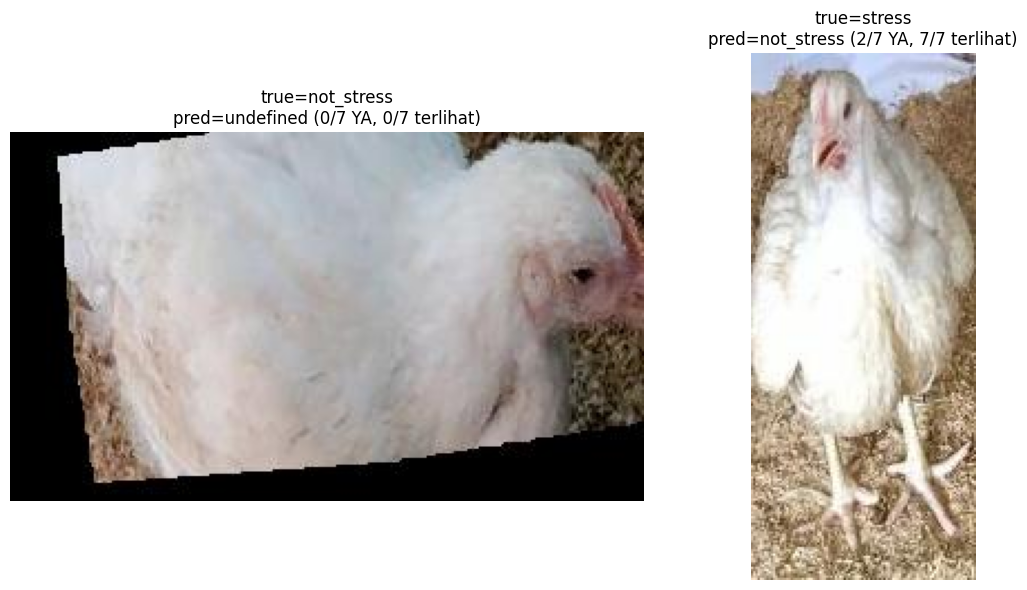

[not_stress] aug_1_not_stress_0006.jpg -> pred=undefined, total_ya=0/7, visible=0/7
  indicators: {'posisi_ekor': 'TIDAK_TERLIHAT', 'posisi_kepala': 'TIDAK_TERLIHAT', 'penutupan_mata': 'TIDAK_TERLIHAT', 'pembukaan_paruh': 'TIDAK_TERLIHAT', 'posisi_sayap': 'TIDAK_TERLIHAT', 'postur_kaki': 'TIDAK_TERLIHAT', 'kondisi_bulu': 'TIDAK_TERLIHAT'}
[stress] stress_0020.jpg -> pred=not_stress, total_ya=2/7, visible=7/7
  indicators: {'posisi_ekor': 'TIDAK', 'posisi_kepala': 'TIDAK', 'penutupan_mata': 'TIDAK', 'pembukaan_paruh': 'YA', 'posisi_sayap': 'TIDAK', 'postur_kaki': 'TIDAK', 'kondisi_bulu': 'YA'}


In [36]:
# Sanity check: coba zero-shot VLM pada beberapa contoh crop train (satu per kelas)
sample_checks = []
for cls in class_to_id:
    folder = os.path.join(DEST, "train", cls)
    files = os.listdir(folder)
    if not files:
        continue
    fname = random.choice(files)
    path = os.path.join(folder, fname)
    result = classify_image_with_vlm(path, vlm_model, processor)
    sample_checks.append((cls, path, result))

fig, axes = plt.subplots(1, len(sample_checks), figsize=(6 * len(sample_checks), 6))
if len(sample_checks) == 1:
    axes = [axes]
for ax, (true_cls, path, result) in zip(axes, sample_checks):
    ax.imshow(Image.open(path))
    ax.axis("off")
    ax.set_title(f"true={true_cls}\npred={result['label']} ({result['total_ya']}/7 YA, {result['visible_count']}/7 terlihat)")
plt.tight_layout()
plt.show()

for true_cls, path, result in sample_checks:
    print(f"[{true_cls}] {os.path.basename(path)} -> pred={result['label']}, total_ya={result['total_ya']}/7, visible={result['visible_count']}/7")
    print("  indicators:", result["indicators"])
    if result["parse_error"]:
        print("  [!] parse_error:", result["parse_error"])


## 3. Train VLM — fine-tuning ringan dengan LoRA

Fine-tuning **tidak** dilakukan full-parameter (risiko overfit besar seperti pada workflow CNN lama), melainkan **LoRA** (Low-Rank Adaptation) di atas VLM pretrained — hanya melatih sebagian kecil parameter tambahan, memakai crop `train` yang sudah dibalancing di notebook 1, dengan early stopping memakai `valid`.

Sudah ada anotasi manual per-indikator asli untuk sebagian crop (dari `indicators_ground_truth_multi.csv`, digabungkan lewat `instance_key` di Bagian 1). Untuk crop yang punya padanan anotasi manual, target fine-tuning sekarang mensupervisi ketujuh indikator SATU-SATU sesuai penilaian manusia  (`build_target_json_from_indicators`) -- bukan lagi ditebak dari label biner. Crop yang BELUM punya anotasi manual tetap fallback ke template lama (`build_target_json`, hanya field `label` yang valid, `indicators` cuma pola buatan) sampai dilabeli manual juga. Lihat print jumlah "target manual asli" vs "target template fallback" di cell konstruksi dataset di bawah untuk tahu proporsinya.

In [37]:
from torch.utils.data import Dataset, DataLoader

def build_target_json(label, indicators=SCS_INDICATORS):
    """PATCH: target fine-tuning template (FALLBACK saja) -- dipakai HANYA untuk crop yang TIDAK
    punya padanan di anotasi manual (indicators_ground_truth_multi.csv). Field 'indicators' di sini
    cuma pola buatan supaya JSON tetap valid, BUKAN ground truth per-indikator sungguhan."""
    if label == "stress":
        ya_keys = [ind["key"] for ind in indicators[:STRESS_THRESHOLD]]
    else:
        ya_keys = []
    ind_dict = {ind["key"]: ("YA" if ind["key"] in ya_keys else "TIDAK") for ind in indicators}
    return json.dumps({"indicators": ind_dict, "label": label}, ensure_ascii=False)


def build_target_json_from_indicators(indicators_dict, label_final, indicators=SCS_INDICATORS):
    """PATCH v3: target fine-tuning dari anotasi manual ASLI (7 indikator + label akhir hasil
    penilaian manusia lewat tool labeling) -- inilah yang memperbaiki masalah target training yang
    sebelumnya cuma 2 kemungkinan template (lihat catatan Cell 50 & analisis kurva loss collapse)."""
    ind_dict = {ind["key"]: str(indicators_dict.get(ind["key"], "TIDAK_TERLIHAT")).upper() for ind in indicators}
    return json.dumps({"indicators": ind_dict, "label": label_final}, ensure_ascii=False)


class VLMFineTuneDataset(Dataset):
    """Pasangan (gambar crop, prompt SCS, target JSON) dari folder DEST/<split>/<kelas>.

    PATCH v3: target_json sekarang dihitung SEKALI saat __init__ (bukan on-the-fly di __getitem__),
    dan dipakai manual_target_lookup (dari Cell crop loop di Bagian 1) kalau crop-nya punya padanan
    anotasi manual asli -- kalau tidak, fallback ke build_target_json(label) seperti sebelumnya.
    """

    def __init__(self, root_dir, class_to_id, manual_target_lookup=None):
        manual_target_lookup = manual_target_lookup or {}
        self.samples = []
        self.n_manual = 0
        self.n_template = 0
        for cls in class_to_id:
            folder = os.path.join(root_dir, cls)
            if not os.path.isdir(folder):
                continue
            for fname in os.listdir(folder):
                path = os.path.join(folder, fname)
                manual = manual_target_lookup.get(path)
                if manual is not None:
                    target_json = build_target_json_from_indicators(manual["indicators"], manual["label_final"])
                    self.n_manual += 1
                else:
                    target_json = build_target_json(cls)
                    self.n_template += 1
                self.samples.append((path, target_json, cls))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


train_ft_ds = VLMFineTuneDataset(os.path.join(DEST, "train"), class_to_id, manual_target_lookup)
valid_ft_ds = VLMFineTuneDataset(os.path.join(DEST, "valid"), class_to_id, manual_target_lookup)

print("Jumlah sampel fine-tuning -- train:", len(train_ft_ds), "| valid:", len(valid_ft_ds))
print(f"  train -- target manual asli: {train_ft_ds.n_manual}, target template fallback: {train_ft_ds.n_template}")
print(f"  valid -- target manual asli: {valid_ft_ds.n_manual}, target template fallback: {valid_ft_ds.n_template}")


Jumlah sampel fine-tuning -- train: 58 | valid: 9
  train -- target manual asli: 52, target template fallback: 6
  valid -- target manual asli: 9, target template fallback: 0


In [ ]:
from peft import LoraConfig, get_peft_model

LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
# PATCH: target module umum untuk arsitektur Qwen2-VL/Qwen3-VL (proyeksi attention Q/K/V/O di language model).
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"]

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    task_type="CAUSAL_LM",
)

# matikan KV-cache (tidak perlu & buang-buang memori pas training,
# cuma penting pas generate/inference), lalu aktifkan gradient checkpointing supaya activation
# memory dibuang & dihitung ulang saat backward, bukan disimpan semua sepanjang forward pass --
# jauh lebih hemat VRAM dengan trade-off sedikit lebih lambat per step.
vlm_model.config.use_cache = False

vlm_model_lora = get_peft_model(vlm_model, lora_config)
vlm_model_lora.gradient_checkpointing_enable()
vlm_model_lora.enable_input_require_grads()  # wajib untuk PEFT + gradient checkpointing bareng base model yang di-freeze
vlm_model_lora.print_trainable_parameters()

trainable params: 5,898,240 || all params: 4,443,714,048 || trainable%: 0.1327


In [ ]:
FT_EPOCHS = 5
FT_PATIENCE = 3          # early stopping -- stop kalau val_loss tidak membaik N epoch berturut-turut
FT_LR = 1e-4

CHECKPOINT_DIR = os.path.join(WORK_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
VLM_LORA_PATH = os.path.join(CHECKPOINT_DIR, "vlm_lora_adapter")


def build_supervised_example(path, target_json, proc,
                              system_prompt=SCS_SYSTEM_PROMPT, user_prompt=SCS_USER_PROMPT):
    """Bangun satu contoh supervised fine-tuning: input = (gambar + prompt SCS), label = token target JSON,
    dengan token bagian prompt di-mask (-100) supaya loss hanya dihitung pada bagian jawaban."""
    image = Image.open(path).convert("RGB")
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": user_prompt}]},
    ]
    prompt_text = proc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    full_text = prompt_text + target_json

    prompt_inputs = proc(text=[prompt_text], images=[image], return_tensors="pt")
    full_inputs = proc(text=[full_text], images=[image], return_tensors="pt")

    labels = full_inputs["input_ids"].clone()
    prompt_len = prompt_inputs["input_ids"].shape[1]
    labels[:, :prompt_len] = -100  # mask bagian prompt, hanya supervisi bagian target JSON

    full_inputs["labels"] = labels
    return full_inputs


def evaluate_val_loss(model, dataset, proc, max_samples=None):
    model.eval()
    losses = []
    samples = dataset.samples if max_samples is None else dataset.samples[:max_samples]
    with torch.no_grad():
        # pakai target_json yang sudah tersimpan di dataset.samples (hasil manual_target_lookup
        # kalau ada), BUKAN menghitung ulang build_target_json(cls) -- supaya val_loss juga konsisten
        # pakai anotasi manual asli, bukan diam-diam kembali ke template.
        for path, target_json, cls in samples:
            batch = build_supervised_example(path, target_json, proc)
            batch = {k: v.to(model.device) for k, v in batch.items()}
            out = model(**batch)
            losses.append(out.loss.item())
    return float(np.mean(losses)) if losses else float("nan")


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch 1/5 -- train_loss=0.1064  val_loss=0.0572
  -> val_loss membaik, checkpoint disimpan ke /kaggle/working/Data_working/checkpoints/vlm_lora_adapter
Epoch 2/5 -- train_loss=0.0563  val_loss=0.0473
  -> val_loss membaik, checkpoint disimpan ke /kaggle/working/Data_working/checkpoints/vlm_lora_adapter
Epoch 3/5 -- train_loss=0.0501  val_loss=0.0343
  -> val_loss membaik, checkpoint disimpan ke /kaggle/working/Data_working/checkpoints/vlm_lora_adapter
Epoch 4/5 -- train_loss=0.0443  val_loss=0.0326
  -> val_loss membaik, checkpoint disimpan ke /kaggle/working/Data_working/checkpoints/vlm_lora_adapter
Epoch 5/5 -- train_loss=0.0388  val_loss=0.0387
  -> val_loss tidak membaik (1/3)


,epoch,train_loss,val_loss
0,1,0.106359,0.057198
1,2,0.056306,0.047278
2,3,0.050105,0.034268
3,4,0.044333,0.032645
4,5,0.038800,0.038702


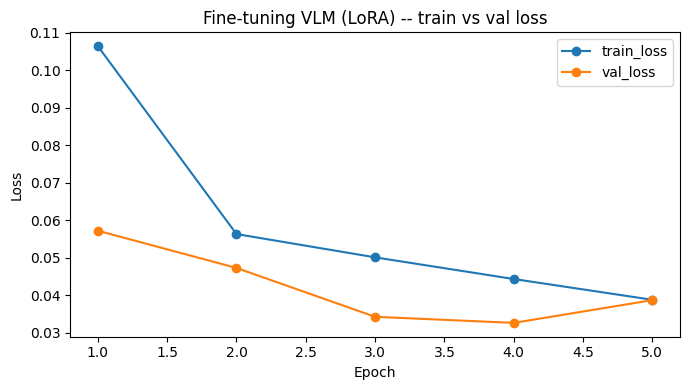

In [40]:
optimizer = torch.optim.AdamW(vlm_model_lora.parameters(), lr=FT_LR)

best_val_loss = float("inf")
epochs_no_improve = 0
history = []

for epoch in range(1, FT_EPOCHS + 1):
    vlm_model_lora.train()
    random.shuffle(train_ft_ds.samples)
    train_losses = []

    for path, target_json, cls in train_ft_ds:
        batch = build_supervised_example(path, target_json, processor)
        batch = {k: v.to(vlm_model_lora.device) for k, v in batch.items()}

        out = vlm_model_lora(**batch)
        loss = out.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses)) if train_losses else float("nan")
    val_loss = evaluate_val_loss(vlm_model_lora, valid_ft_ds, processor)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    print(f"Epoch {epoch}/{FT_EPOCHS} -- train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        vlm_model_lora.save_pretrained(VLM_LORA_PATH)  # PATCH: simpan HANYA saat val_loss membaik
        print(f"  -> val_loss membaik, checkpoint disimpan ke {VLM_LORA_PATH}")
    else:
        epochs_no_improve += 1
        print(f"  -> val_loss tidak membaik ({epochs_no_improve}/{FT_PATIENCE})")
        if epochs_no_improve >= FT_PATIENCE:
            print("Early stopping.")
            break

history_df = pd.DataFrame(history)
display(history_df)

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-tuning VLM (LoRA) -- train vs val loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "vlm_finetune_loss.png"), dpi=200, bbox_inches="tight")
plt.show()


## 4. Simpan konfigurasi & checkpoint VLM (bridging ke `03_evaluate.ipynb`)

Yang disimpan bukan bobot model dasar (terlalu besar & sudah tersedia dari HuggingFace), melainkan:
- Nama/versi VLM dasar (`VLM_MODEL_NAME`) supaya `03_evaluate.ipynb` memuat model yang sama.
- Path adapter LoRA hasil fine-tuning terbaik (`VLM_LORA_PATH`).
- Rules SCS (`SCS_INDICATORS`, `STRESS_THRESHOLD`, prompt) supaya evaluasi memakai rule yang identik.

In [ ]:
vlm_experiments = {
    "zero_shot": {
        "label": "Zero-shot VLM (SCS prompt)",
        "model_name": VLM_MODEL_NAME,
        "adapter_path": None,
    },
    "fine_tuned": {
        "label": "Fine-tuned VLM (SCS prompt + LoRA)",
        "model_name": VLM_MODEL_NAME,
        "adapter_path": VLM_LORA_PATH if os.path.exists(VLM_LORA_PATH) else None,
    },
    "_meta": {
        "scs_indicators": SCS_INDICATORS,
        "stress_threshold": STRESS_THRESHOLD,
        "min_visible_indicators": MIN_VISIBLE_INDICATORS,  # dipakai utk rule undefined
        "class_names_3": CLASS_NAMES_3,                    # ["not_stress", "stress", "undefined"]
        "system_prompt": SCS_SYSTEM_PROMPT,
        "user_prompt": SCS_USER_PROMPT,
        "ft_epochs_run": len(history),
        "ft_patience": FT_PATIENCE,
        "best_val_loss": best_val_loss,
    },
}

VLM_REGISTRY_PATH = os.path.join(WORK_DIR, "vlm_experiments.pkl")
with open(VLM_REGISTRY_PATH, "wb") as f:
    pickle.dump(vlm_experiments, f)

print("Konfigurasi & checkpoint VLM disimpan ke:", VLM_REGISTRY_PATH)
for name, info in vlm_experiments.items():
    if name == "_meta":
        continue
    print(" -", name, "->", info)


Konfigurasi & checkpoint VLM disimpan ke: /kaggle/working/Data_working/vlm_experiments.pkl
 - zero_shot -> {'label': 'Zero-shot VLM (SCS prompt)', 'model_name': 'Qwen/Qwen3-VL-4B-Instruct', 'adapter_path': None}
 - fine_tuned -> {'label': 'Fine-tuned VLM (SCS prompt + LoRA)', 'model_name': 'Qwen/Qwen3-VL-4B-Instruct', 'adapter_path': '/kaggle/working/Data_working/checkpoints/vlm_lora_adapter'}


# Bagian 3 — Evaluasi VLM (Zero-shot vs Fine-tuned)


# ChickenStress — 03. Evaluasi VLM (Zero-shot vs Fine-tuned)

**(Workflow Change Request — Project Poultry):** menggantikan seluruh isi lama
evaluasi 6 konfigurasi detector+CNN dengan matching IoU mengikuti alur baru:

`Image Dataset → Image Preprocessing → Use & Train VLM → Classification → Evaluation`

Karena workflow baru mengklasifikasi langsung di level crop (satu ayam per gambar, hasil *Image Preprocessing*
di notebook 1) dan tidak lagi melatih detector sendiri, evaluasi di sini **tidak lagi memakai IoU matching**.
Evaluasi membandingkan dua konfigurasi dari bagian 2`:
1. **Zero-shot VLM (SCS prompt)** — VLM pretrained + prompt Stressed Chicken Scale, tanpa fine-tuning.
2. **Fine-tuned VLM (SCS prompt + LoRA)** — VLM yang sama + adapter LoRA hasil training di notebook 2.

Ground truth = label folder (`not_stress` / `stress`) di `DEST/test/<kelas>/`. Untuk tiap eksperimen disimpan:
- `classification_report.txt` (precision/recall/F1 per kelas)
- `confusion_matrix.png`
ke `WORK_DIR/evaluation_results/<nama_eksperimen>/`, sama seperti notebook evaluasi versi lama.

---
**Update terbaru, mengikuti Bagian 2:**
- **3 kelas evaluasi**: `not_stress`, `stress`, `undefined`. Ground truth (folder `DEST/test`) tetap cuma 2
  kelas (foto training/evaluasi selalu difoto/di-crop utuh satu ekor ayam), tapi VLM sekarang bisa
  MEMPREDIKSI `undefined` kalau foto kurang dari `MIN_VISIBLE_INDICATORS` indikator yang terlihat (misal
  ke-crop cuma sampai kepala) — jadi confusion matrix & classification report sekarang 3 kolom prediksi
  x 2 baris ground truth (`undefined` tidak pernah muncul sebagai baris karena tidak ada foto training yang
  sengaja dilabeli 'undefined').

## 0. Label space evaluasi (3 kelas)
Variabel dari Bagian 2 (`SCS_INDICATORS`, `STRESS_THRESHOLD`, `SCS_SYSTEM_PROMPT`, `SCS_USER_PROMPT`, `vlm_experiments`, dst.) sudah ada di memori -- cell di bawah cuma membangun ulang label space evaluasi 3-kelas (`not_stress` / `stress` / `undefined`) dari `vlm_experiments["_meta"]`, tanpa perlu baca file pickle.

In [42]:
_meta = vlm_experiments["_meta"]
SCS_INDICATORS = _meta["scs_indicators"]
STRESS_THRESHOLD = _meta["stress_threshold"]
SCS_SYSTEM_PROMPT = _meta["system_prompt"]
SCS_USER_PROMPT = _meta["user_prompt"]
MIN_VISIBLE_INDICATORS = _meta.get("min_visible_indicators", 4)
CLASS_NAMES_3 = _meta.get("class_names_3", ["not_stress", "stress", "undefined"])

# PATCH: id mapping KHUSUS evaluasi (3 kelas: not_stress=0, stress=1, undefined=2) -- BEDA dari
# `class_to_id` bawaan Bagian 1 (cuma 2 kelas, dipakai untuk nama folder ground truth di DEST/test).
class_to_id_eval = {name: i for i, name in enumerate(CLASS_NAMES_3)}
id_to_class_eval = {i: name for name, i in class_to_id_eval.items()}

print("Ambang label SCS: >=", STRESS_THRESHOLD, "dari", len(SCS_INDICATORS), "indikator -> stress")
print("Minimal indikator terlihat: >=", MIN_VISIBLE_INDICATORS, "dari", len(SCS_INDICATORS), "-- kurang -> 'undefined'")
print("Label space evaluasi (3 kelas):", class_to_id_eval)
for name, info in vlm_experiments.items():
    if name == "_meta":
        continue
    print(" -", name, "->", info)


Ambang label SCS: >= 3 dari 7 indikator -> stress
Minimal indikator terlihat: >= 5 dari 7 -- kurang -> 'undefined'
Label space evaluasi (3 kelas): {'not_stress': 0, 'stress': 1, 'undefined': 2}
 - zero_shot -> {'label': 'Zero-shot VLM (SCS prompt)', 'model_name': 'Qwen/Qwen3-VL-4B-Instruct', 'adapter_path': None}
 - fine_tuned -> {'label': 'Fine-tuned VLM (SCS prompt + LoRA)', 'model_name': 'Qwen/Qwen3-VL-4B-Instruct', 'adapter_path': '/kaggle/working/Data_working/checkpoints/vlm_lora_adapter'}


## 1. Fungsi rule SCS & parsing output VLM 
Disalin ulang di sini (bukan di-import) supaya notebook ini tetap bisa dijalankan berdiri sendiri asal
`vlm_experiments.pkl` & `pipeline_artifacts.pkl` sudah ada.

In [43]:
import re

def parse_vlm_json(raw_text):
    match = re.search(r"\{.*\}", raw_text, flags=re.DOTALL)
    if not match:
        raise ValueError(f"Tidak ditemukan JSON pada output VLM: {raw_text!r}")
    return json.loads(match.group(0))


def normalize_indicator_answer(raw_value):
    """PATCH (kelas ke-3): identik dengan 02_models.ipynb -- normalisasi ke 'YA' / 'TIDAK' / 'TIDAK_TERLIHAT',
    default ke 'TIDAK_TERLIHAT' kalau kosong/tidak dikenali (lebih aman daripada diam-diam jadi 'TIDAK')."""
    raw_val = str(raw_value).strip().upper().replace(" ", "_")
    if raw_val.startswith("YA"):
        return "YA"
    if raw_val.startswith("TIDAK_TERLIHAT") or raw_val in {"TT", "NA", "N/A", "TIDAK_ADA", "TIDAK_TAMPAK", "NONE", ""}:
        return "TIDAK_TERLIHAT"
    if raw_val.startswith("TIDAK"):
        return "TIDAK"
    return "TIDAK_TERLIHAT"


def apply_scs_rule(indicators_dict, indicators=SCS_INDICATORS, threshold=STRESS_THRESHOLD,
                    min_visible=MIN_VISIBLE_INDICATORS):
    """PATCH -- identik dengan 02_models.ipynb (3 kelas: 'undefined' kalau indikator yang terlihat
    < min_visible dari 7; kalau tidak, 'stress'/'not_stress' berdasarkan ambang total 'YA')."""
    total_ya = 0
    visible_count = 0
    normalized = {}
    for ind in indicators:
        answer = normalize_indicator_answer(indicators_dict.get(ind["key"], "TIDAK_TERLIHAT"))
        normalized[ind["key"]] = answer
        if answer != "TIDAK_TERLIHAT":
            visible_count += 1
        if answer == "YA":
            total_ya += 1

    if visible_count < min_visible:
        label = "undefined"
    else:
        label = "stress" if total_ya >= threshold else "not_stress"

    score_stress = total_ya / len(indicators)
    return normalized, total_ya, visible_count, label, score_stress


## 2. Muat ulang VLM (base + adapter LoRA opsional)

In [ ]:
import gc

# `optimizer` masih nyimpen referensi ke SEMUA parameter vlm_model_lora (AdamW nyimpen
# param groups), jadi walau vlm_model/vlm_model_lora sudah di-del, tensornya TETAP nggak bisa
# di-garbage-collect selama optimizer masih hidup 
for _name in ["optimizer", "vlm_model_lora", "vlm_model", "out", "loss", "batch"]:
    if _name in globals():
        del globals()[_name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    print(f"GPU memory terpakai setelah dibersihkan: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
else:
    print("Device bukan CUDA, tidak ada yang perlu dibersihkan.")

GPU memory terpakai setelah dibersihkan: 0.02 GB


In [ ]:
from peft import PeftModel
from transformers import AutoProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

BASE_MODEL_NAME = vlm_experiments["zero_shot"]["model_name"]

# (fix OOM): samakan resolusi dengan processor yang dipakai saat fine-tuning di Bagian 2 --
# kalau beda, evaluasi jalan di distribusi resolusi berbeda dari yang di-training (bias hasil),
# dan ikut lebih boros memori kalau resolusinya lebih besar dari yang dipakai training.
processor = AutoProcessor.from_pretrained(
    BASE_MODEL_NAME,
    min_pixels=256 * 28 * 28,
    max_pixels=512 * 28 * 28,
)


def load_vlm_base_model(model_name):
    """PATCH (fix ImportError + fix OOM): identik dengan load_vlm_model_and_processor() di Bagian 2 --
    tambah jalur kelas spesifik Qwen3-VL, dan `dtype=` (bukan `torch_dtype=` yang deprecated & TIDAK
    kepakai lagi di transformers terbaru -- itu yang bikin model kemarin diam-diam kemuat fp32,
    2x lebih besar dari yang seharusnya)."""
    import transformers as _tf
    model_dtype = torch.float16 if device == "cuda" else torch.float32  # T4 = fp16
    errors = []

    if "qwen3-vl" in model_name.lower() or "qwen3_vl" in model_name.lower():
        try:
            from transformers import Qwen3VLForConditionalGeneration
            return Qwen3VLForConditionalGeneration.from_pretrained(
                model_name, dtype=model_dtype, low_cpu_mem_usage=True,
            )
        except Exception as e:
            errors.append(f"Qwen3VLForConditionalGeneration: {e}")

    try:
        from transformers import AutoModelForImageTextToText
        return AutoModelForImageTextToText.from_pretrained(
            model_name, dtype=model_dtype, low_cpu_mem_usage=True,
        )
    except Exception as e:
        errors.append(f"AutoModelForImageTextToText: {e}")

    try:
        from transformers import AutoModelForVision2Seq
        return AutoModelForVision2Seq.from_pretrained(
            model_name, dtype=model_dtype, low_cpu_mem_usage=True,
        )
    except Exception as e:
        errors.append(f"AutoModelForVision2Seq: {e}")

    if "qwen2-vl" in model_name.lower() or "qwen2_vl" in model_name.lower():
        try:
            from transformers import Qwen2VLForConditionalGeneration
            return Qwen2VLForConditionalGeneration.from_pretrained(
                model_name, dtype=model_dtype, low_cpu_mem_usage=True,
            )
        except Exception as e:
            errors.append(f"Qwen2VLForConditionalGeneration: {e}")

    raise ImportError(
        "Tidak berhasil memuat VLM dengan versi `transformers` yang terpasang "
        f"({_tf.__version__}). Semua jalur gagal:\n  - " + "\n  - ".join(errors) +
        "\n\n>> Jalankan: pip install -q -U \"transformers>=4.57.0\" lalu RESTART KERNEL."
    )


if torch.cuda.is_available():
    torch.cuda.empty_cache()

base_vlm_model = load_vlm_base_model(BASE_MODEL_NAME).to(device)
base_vlm_model.eval()

print("Dtype base_vlm_model:", next(base_vlm_model.parameters()).dtype)

adapter_path = vlm_experiments["fine_tuned"]["adapter_path"]
if adapter_path and os.path.exists(adapter_path):
    # (fix bug: metrik zero-shot == fine-tuned):
    # PeftModel.from_pretrained() MENEMPEL adapter LoRA ke base_vlm_model yang SAMA secara
    # IN-PLACE -- ini memang efisien untuk VRAM (base_vlm_model & finetuned_vlm_model berbagi
    # bobot dasar, bukan sumber OOM), TAPI ada efek samping penting yang sebelumnya tidak
    # ditangani: setelah baris ini jalan, layer target LoRA (q_proj/k_proj/v_proj/o_proj) di
    # DALAM base_vlm_model ikut berubah jadi `peft.tuners.lora.Linear`, dan adapter AKTIF
    # secara default. Artinya memanggil `base_vlm_model(...)` langsung SETELAH baris ini
    # TIDAK lagi murni zero-shot -- forward pass-nya tetap ikut menghitung delta LoRA, karena
    # entry point apa pun (base_vlm_model atau finetuned_vlm_model) menyentuh pohon modul yang
    # sama persis. Ini akar bug kenapa hasil evaluasi zero-shot & fine-tuned identik.
    #
    # FIX: jangan panggil base_vlm_model langsung lagi untuk jalur zero-shot
    # Pakai `finetuned_vlm_model.disable_adapter()` (context manager PEFT) untuk sementara
    # menonaktifkan delta LoRA saat inferensi zero-shot, baru enable lagi otomatis begitu keluar
    # blok `with`. Ini menghindari perlu load bobot base dua kali (hemat VRAM tetap tercapai).
    finetuned_vlm_model = PeftModel.from_pretrained(base_vlm_model, adapter_path)
    finetuned_vlm_model.eval()
    print("Adapter LoRA dimuat dari:", adapter_path)

    # --- Sanity check: konfirmasi injeksi LoRA & adapter benar-benar aktif ---
    _lora_layers_found = 0
    for _name, _module in finetuned_vlm_model.named_modules():
        if _module.__class__.__name__.startswith("Lora"):
            _lora_layers_found += 1
    print(f"[sanity check] Jumlah submodule ber-tipe Lora*: {_lora_layers_found} "
          f"(harus > 0 kalau adapter berhasil ter-inject)")
    print(f"[sanity check] Adapter aktif di finetuned_vlm_model: "
          f"{finetuned_vlm_model.active_adapters}")
    print("[!] PENTING: base_vlm_model sekarang JUGA membawa layer LoRA di atas (in-place). "
          "Jangan pakai base_vlm_model langsung untuk zero-shot -- pakai "
          "finetuned_vlm_model.disable_adapter() (lihat Cell 66).")
else:
    finetuned_vlm_model = None
    print("[!] Adapter LoRA tidak ditemukan -- eksperimen 'fine_tuned' akan dilewati "
          "(jalankan fine-tuning di 02_models.ipynb terlebih dahulu).")

Device: cuda


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

Dtype base_vlm_model: torch.float16
Adapter LoRA dimuat dari: /kaggle/working/Data_working/checkpoints/vlm_lora_adapter
[sanity check] Jumlah submodule ber-tipe Lora*: 1 (harus > 0 kalau adapter berhasil ter-inject)
[sanity check] Adapter aktif di finetuned_vlm_model: ['default']
[!] PENTING: base_vlm_model sekarang JUGA membawa layer LoRA di atas (in-place). Jangan pakai base_vlm_model langsung untuk zero-shot -- pakai finetuned_vlm_model.disable_adapter() (lihat Cell 66).


In [ ]:
def run_vlm_raw(image_path, model, proc, system_prompt=SCS_SYSTEM_PROMPT, user_prompt=SCS_USER_PROMPT,
                 max_new_tokens=400):
    image = Image.open(image_path).convert("RGB")
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": user_prompt}]},
    ]
    chat_text = proc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = proc(text=[chat_text], images=[image], return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    trimmed = output_ids[:, inputs["input_ids"].shape[1]:]
    text = proc.batch_decode(trimmed, skip_special_tokens=True)[0]
    return text


def classify_image_with_vlm(image_path, model, proc):
    """PATCH (kelas ke-3): identik dengan 02_models.ipynb -- kalau parsing JSON gagal total, semua
    indikator dianggap 'TIDAK_TERLIHAT' sehingga apply_scs_rule otomatis menghasilkan label 'undefined'."""
    raw_text = run_vlm_raw(image_path, model, proc)
    try:
        parsed = parse_vlm_json(raw_text)
        indicators_raw = parsed.get("indicators", {})
        normalized, total_ya, visible_count, label, score = apply_scs_rule(indicators_raw)
        parse_error = None
    except Exception as e:
        normalized, total_ya, visible_count, label, score = apply_scs_rule(
            {ind["key"]: "TIDAK_TERLIHAT" for ind in SCS_INDICATORS}
        )
        parse_error = str(e)

    return {
        "image_path": image_path,
        "indicators": normalized,
        "total_ya": total_ya,
        "visible_count": visible_count,
        "label": label,
        "score_stress": score,
        "raw_response": raw_text,
        "parse_error": parse_error,
    }



# FIX: pakai context manager `finetuned_vlm_model.disable_adapter()` dari PEFT untuk jalur
# zero-shot. Context manager ini menonaktifkan SEMUA delta LoRA sementara di dalam blok `with`
# (forward pass jadi murni bobot base), lalu otomatis mengaktifkan kembali begitu keluar blok --
# tanpa perlu load model dasar dua kali / duplikat di VRAM (tujuan hemat memori di Cell 65 tetap
# tercapai).

def classify_zero_shot_fn(path):
    """Jalur zero-shot yang BENAR: kalau ada finetuned_vlm_model (adapter ter-load), pakai model
    itu tapi dengan adapter di-disable sementara -- supaya forward pass benar-benar murni base
    weights, bukan base_vlm_model yang sudah "tercemar" LoRA. Kalau tidak ada adapter sama sekali
    (finetuned_vlm_model is None), base_vlm_model memang masih murni base -> aman dipakai langsung.
    """
    if finetuned_vlm_model is not None:
        with finetuned_vlm_model.disable_adapter():
            return classify_image_with_vlm(path, finetuned_vlm_model, processor)
    return classify_image_with_vlm(path, base_vlm_model, processor)


# Dua fungsi klasifikasi yang dibandingkan di evaluasi ini
classify_zero_shot = classify_zero_shot_fn
classify_fine_tuned = (
    (lambda path: classify_image_with_vlm(path, finetuned_vlm_model, processor))
    if finetuned_vlm_model is not None else None
)

# --- Sanity check tambahan: pastikan dua jalur ini benar-benar menghasilkan output berbeda
# --- pada gambar yang sama, sebelum lanjut ke evaluasi penuh (Cell 68-69) yang mahal.
if finetuned_vlm_model is not None:
    _probe_dir = None
    for _cls in class_to_id:
        _folder = os.path.join(DEST, "test", _cls)
        if os.path.isdir(_folder) and os.listdir(_folder):
            _probe_dir = _folder
            break
    if _probe_dir is not None:
        _probe_path = os.path.join(_probe_dir, os.listdir(_probe_dir)[0])
        _zs = classify_zero_shot(_probe_path)
        _ft = classify_fine_tuned(_probe_path)
        print(f"[sanity check] Probe gambar: {os.path.basename(_probe_path)}")
        print(f"  zero-shot   -> label={_zs['label']}  total_ya={_zs['total_ya']}/7  "
              f"raw_response[:80]={_zs['raw_response'][:80]!r}")
        print(f"  fine-tuned  -> label={_ft['label']}  total_ya={_ft['total_ya']}/7  "
              f"raw_response[:80]={_ft['raw_response'][:80]!r}")
        if _zs["raw_response"] == _ft["raw_response"]:
            print("  [!] PERINGATAN: raw_response IDENTIK -- kemungkinan adapter masih tidak "
                  "kebedakan (cek ulang disable_adapter() / adapter_path benar-benar ter-load).")
        else:
            print("  [OK] raw_response berbeda -- adapter LoRA terbukti berpengaruh ke output.")

[sanity check] Probe gambar: not_stress_0003.jpg
  zero-shot   -> label=undefined  total_ya=0/7  raw_response[:80]='{\n  "indicators": {\n    "posisi_ekor": "TIDAK",\n    "posisi_kepala": "TIDAK_TERL'
  fine-tuned  -> label=stress  total_ya=3/7  raw_response[:80]='{"indicators": {"posisi_ekor": "TIDAK", "posisi_kepala": "TIDAK", "penutupan_mat'
  [OK] raw_response berbeda -- adapter LoRA terbukti berpengaruh ke output.


## 3. Evaluasi Terpadu — Zero-shot vs Fine-tuned VLM

Setiap gambar di `DEST/test/<kelas>/` diklasifikasi oleh VLM, label akhir dihitung memakai rule SCS
(`apply_scs_rule`), lalu dibandingkan dengan label folder (ground truth).

In [47]:
def evaluate_vlm_pipeline(classify_fn, gt_class_to_id, pred_class_to_id, dest_dir=DEST, split="test",
                           manual_target_lookup=None):
    """PATCH v4 (FIX: ground truth 'undefined' tidak pernah muncul di eval): sebelumnya ground truth
    SELALU diambil dari nama folder (gt_class_to_id), yang cuma ada 2 kemungkinan (stress/not_stress)
    -- 'undefined' TIDAK PERNAH bisa jadi ground truth apapun yang terjadi, meski ada anotasi manual
    'undefined' untuk instance itu, karena foldernya sendiri cuma stress/not_stress (ditentukan aturan
    binary lama). Sekarang: kalau crop ini punya padanan di manual_target_lookup, ground truth-nya
    PAKAI label_final dari situ (bisa undefined) -- folder cuma dipakai untuk tahu di mana filenya ada,
    bukan lagi sumber kebenaran. Crop yang belum dilabeli manual tetap pakai nama folder seperti biasa.

    'pred_class_to_id' tetap dipakai untuk encode y_true & y_pred (3 kelas: not_stress/stress/undefined)
    supaya baik ground truth manual maupun prediksi model yang 'undefined' sama-sama ke-map dengan benar.
    """
    manual_target_lookup = manual_target_lookup or {}
    y_true, y_pred, y_score, records = [], [], [], []
    for cls in gt_class_to_id:
        folder = os.path.join(dest_dir, split, cls)
        if not os.path.isdir(folder):
            continue
        for fname in os.listdir(folder):
            path = os.path.join(folder, fname)
            manual = manual_target_lookup.get(path)
            true_label = manual["label_final"] if manual is not None else cls
            result = classify_fn(path)
            y_true.append(pred_class_to_id[true_label])
            y_pred.append(pred_class_to_id[result["label"]])
            y_score.append(result["score_stress"])
            records.append({
                "file_name": fname,
                "true_label": true_label,
                "true_label_source": "manual_annotation" if manual is not None else "folder_binary",
                **result,
            })
    return y_true, y_pred, y_score, pd.DataFrame(records)


In [48]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def safe_folder_name(name):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", name).strip("_")

EVAL_DIR = os.path.join(WORK_DIR, "evaluation_results")
os.makedirs(EVAL_DIR, exist_ok=True)

# PATCH (kelas ke-3): label space evaluasi sekarang class_to_id_eval/id_to_class_eval (3 kelas),
# bukan lagi class_to_id bawaan notebook 1 (2 kelas).
label_ids = sorted(id_to_class_eval.keys())
target_names = [id_to_class_eval[i] for i in label_ids]

pipelines = {
    "zero_shot": classify_zero_shot,
    "fine_tuned": classify_fine_tuned,
}

results_summary = {}
raw_predictions = {}

for key, classify_fn in pipelines.items():
    exp_label = vlm_experiments[key]["label"]
    if classify_fn is None:
        print(f"[SKIP] {exp_label}: fungsi klasifikasi tidak tersedia.")
        continue

    print(f"Mengevaluasi: {exp_label} ...")
    y_true, y_pred, y_score, df_records = evaluate_vlm_pipeline(
        classify_fn, class_to_id, class_to_id_eval, manual_target_lookup=manual_target_lookup
    )
    raw_predictions[key] = df_records

    if not y_true:
        print(f"  [!] Tidak ada sampel test untuk dievaluasi, dilewati.")
        continue

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    report = classification_report(y_true, y_pred, labels=label_ids, target_names=target_names, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=label_ids)

    exp_dir = os.path.join(EVAL_DIR, safe_folder_name(exp_label))
    os.makedirs(exp_dir, exist_ok=True)

    with open(os.path.join(exp_dir, "classification_report.txt"), "w") as f:
        f.write(f"{exp_label}\n")
        f.write(f"accuracy={acc:.4f}  f1_macro={f1_macro:.4f}\n\n")
        f.write(report)

    df_records.to_csv(os.path.join(exp_dir, "predictions.csv"), index=False)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"Confusion Matrix\n{exp_label}")
    plt.xticks(range(len(target_names)), target_names, rotation=30, ha="right")
    plt.yticks(range(len(target_names)), target_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout()
    plt.savefig(os.path.join(exp_dir, "confusion_matrix.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # PATCH (kelas ke-3): seberapa sering VLM "angkat tangan" (undefined) alih-alih menjawab tegas.
    undefined_rate = (df_records["label"] == "undefined").mean()
    results_summary[exp_label] = {
        "accuracy": acc, "f1_macro": f1_macro, "undefined_rate": undefined_rate, "n_test": len(y_true),
    }
    print(f"  accuracy={acc:.4f}  f1_macro={f1_macro:.4f}  undefined_rate={undefined_rate:.2%}  (n={len(y_true)})")
    print(f"  Hasil disimpan ke: {exp_dir}")

print("\nSelesai. Ringkasan:")
results_df = pd.DataFrame(results_summary).T.sort_values("f1_macro", ascending=False)
display(results_df)


Mengevaluasi: Zero-shot VLM (SCS prompt) ...
  accuracy=0.3750  f1_macro=0.2500  undefined_rate=62.50%  (n=8)
  Hasil disimpan ke: /kaggle/working/Data_working/evaluation_results/Zero-shot_VLM_SCS_prompt
Mengevaluasi: Fine-tuned VLM (SCS prompt + LoRA) ...
  accuracy=1.0000  f1_macro=1.0000  undefined_rate=37.50%  (n=8)
  Hasil disimpan ke: /kaggle/working/Data_working/evaluation_results/Fine-tuned_VLM_SCS_prompt_LoRA

Selesai. Ringkasan:


,accuracy,f1_macro,undefined_rate,n_test
Fine-tuned VLM (SCS prompt + LoRA),1.000,1.00,0.375,8.0
Zero-shot VLM (SCS prompt),0.375,0.25,0.625,8.0


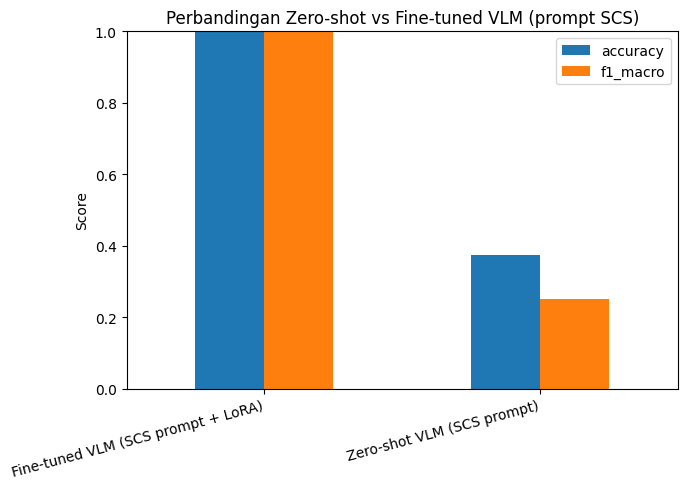

In [49]:
results_df[["accuracy", "f1_macro"]].plot(kind="bar", figsize=(7, 5))
plt.title("Perbandingan Zero-shot vs Fine-tuned VLM (prompt SCS)")
plt.ylabel("Score")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, "comparison_bar_chart.png"), dpi=200, bbox_inches="tight")
plt.show()


## 4. Ringkasan Konfigurasi Terbaik

Konfigurasi terbaik: Fine-tuned VLM (SCS prompt + LoRA)
Classification report: /kaggle/working/Data_working/evaluation_results/Fine-tuned_VLM_SCS_prompt_LoRA/classification_report.txt
Confusion matrix: /kaggle/working/Data_working/evaluation_results/Fine-tuned_VLM_SCS_prompt_LoRA/confusion_matrix.png
Fine-tuned VLM (SCS prompt + LoRA)
accuracy=1.0000  f1_macro=1.0000

              precision    recall  f1-score   support

  not_stress       1.00      1.00      1.00         1
      stress       1.00      1.00      1.00         4
   undefined       1.00      1.00      1.00         3

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



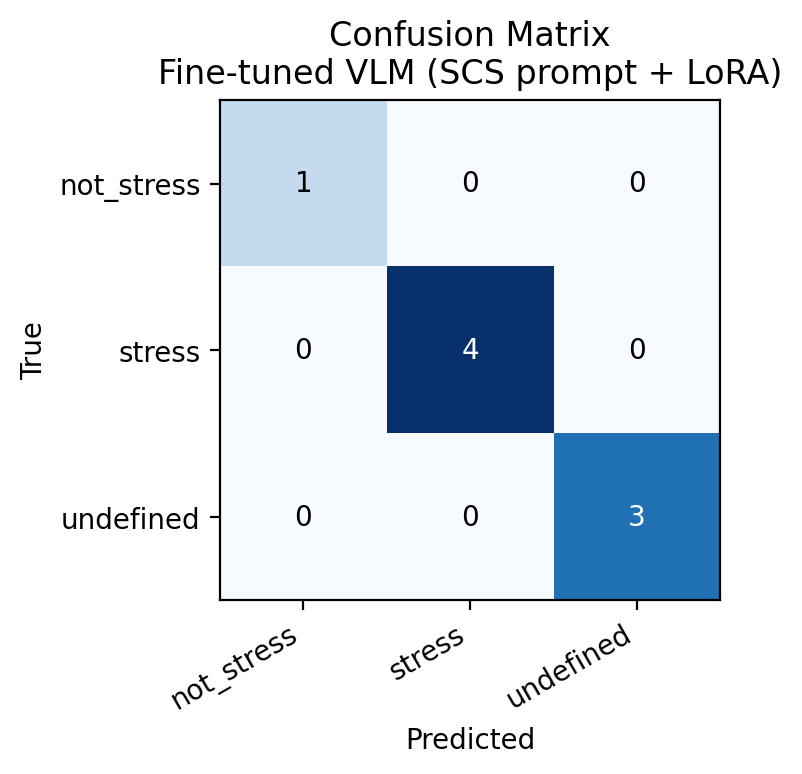

In [50]:
best_config = results_df.index[0]
best_dir = os.path.join(EVAL_DIR, safe_folder_name(best_config))

print("Konfigurasi terbaik:", best_config)
print("Classification report:", os.path.join(best_dir, "classification_report.txt"))
print("Confusion matrix:", os.path.join(best_dir, "confusion_matrix.png"))

with open(os.path.join(best_dir, "classification_report.txt")) as f:
    print(f.read())

from IPython.display import Image as IPyImage, display
display(IPyImage(filename=os.path.join(best_dir, "confusion_matrix.png")))


## 5. Evaluasi Lanjutan

Melengkapi evaluasi dasar (accuracy, f1-macro, classification report, confusion matrix) di atas dengan:
**balanced accuracy**, **Cohen's kappa**, **ROC-AUC**/**PR-AUC** (memakai `score_stress = total_ya/7` sebagai
skor probabilitas kelas *stress*), dan **calibration curve** — sama seperti notebook evaluasi versi lama,
tapi sekarang hanya untuk 2 konfigurasi (zero-shot & fine-tuned VLM), bukan 6.

In [51]:
from sklearn.metrics import (
    balanced_accuracy_score, cohen_kappa_score, roc_auc_score, average_precision_score,
)
from sklearn.calibration import calibration_curve

# PATCH (kelas ke-3): pakai class_to_id_eval (3 kelas), bukan class_to_id bawaan notebook 1.
stress_id = class_to_id_eval["stress"]

extended_metrics = {}
calibration_data = {}

for key, df_records in raw_predictions.items():
    exp_label = vlm_experiments[key]["label"]
    if df_records.empty:
        continue

    y_true = df_records["true_label"].map(class_to_id_eval).tolist()
    y_pred = df_records["label"].map(class_to_id_eval).tolist()
    y_score = df_records["score_stress"].tolist()
    y_true_bin = [int(t == stress_id) for t in y_true]

    metrics = {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
    }
    if len(set(y_true_bin)) > 1:
        metrics["roc_auc"] = roc_auc_score(y_true_bin, y_score)
        metrics["pr_auc"] = average_precision_score(y_true_bin, y_score)
    else:
        metrics["roc_auc"] = float("nan")
        metrics["pr_auc"] = float("nan")

    n_parse_error = df_records["parse_error"].notna().sum()
    metrics["n_parse_error"] = int(n_parse_error)  # PATCH: berapa kali VLM gagal dijawab dalam format JSON valid

    extended_metrics[exp_label] = metrics
    calibration_data[exp_label] = (y_true_bin, y_score)

extended_df = pd.DataFrame(extended_metrics).T
display(extended_df)
extended_df.to_csv(os.path.join(EVAL_DIR, "extended_metrics.csv"))


,balanced_accuracy,cohen_kappa,roc_auc,pr_auc,n_parse_error
Zero-shot VLM (SCS prompt),0.333333,0.130435,0.375,0.5,0.0
Fine-tuned VLM (SCS prompt + LoRA),1.000000,1.000000,1.000,1.0,0.0


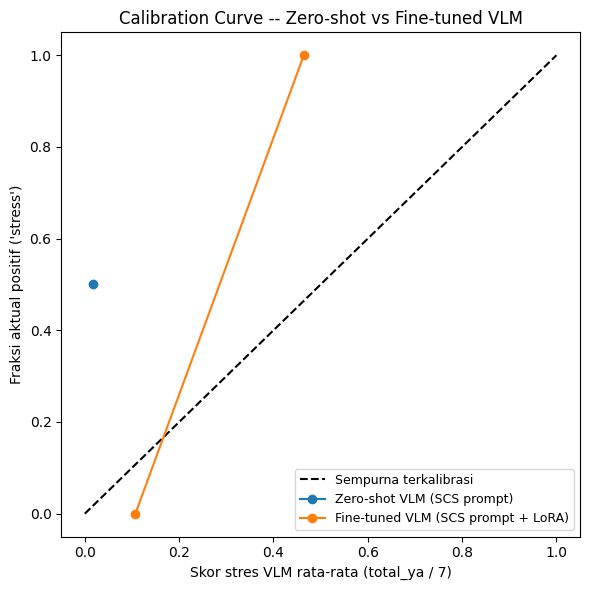

In [52]:
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="Sempurna terkalibrasi")
for exp_label, (y_true_bin, y_score) in calibration_data.items():
    if len(set(y_true_bin)) < 2:
        continue
    frac_pos, mean_pred = calibration_curve(y_true_bin, y_score, n_bins=5)
    plt.plot(mean_pred, frac_pos, marker="o", label=exp_label)
plt.xlabel("Skor stres VLM rata-rata (total_ya / 7)")
plt.ylabel("Fraksi aktual positif ('stress')")
plt.title("Calibration Curve -- Zero-shot vs Fine-tuned VLM")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, "calibration_curves.png"), dpi=200, bbox_inches="tight")
plt.show()


## 6. Interpretabilitas — breakdown 7 indikator SCS

Berbeda dari workflow lama (Grad-CAM/attention map pada CNN), VLM di sini **secara langsung** melaporkan
indikator SCS mana yang dianggap "YA" — jadi interpretabilitasnya sudah eksplisit tanpa perlu heatmap
tambahan. Sel di bawah menampilkan gambar contoh per kelas beserta breakdown 7 indikatornya, supaya bisa
dicek apakah alasan VLM (bagian tubuh mana yang dinilai stres) masuk akal secara visual.

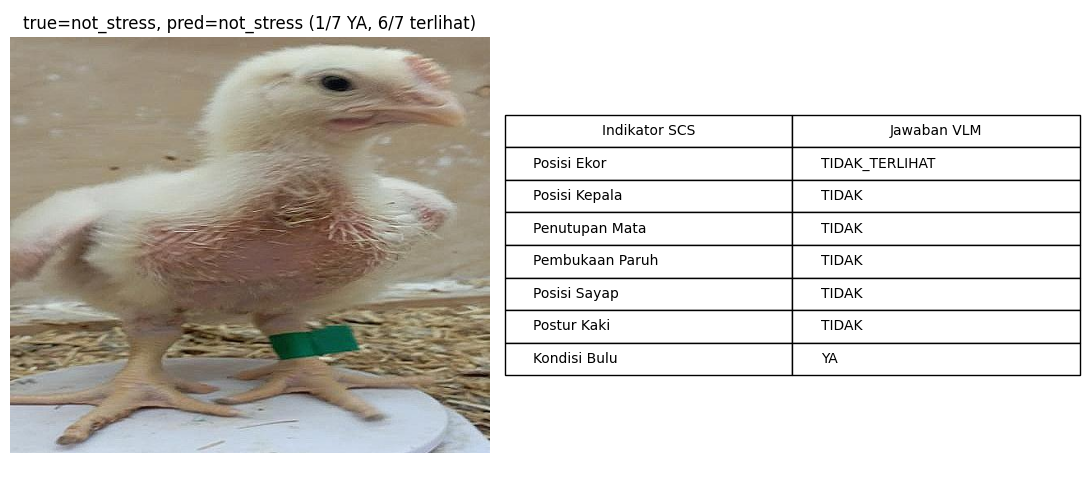

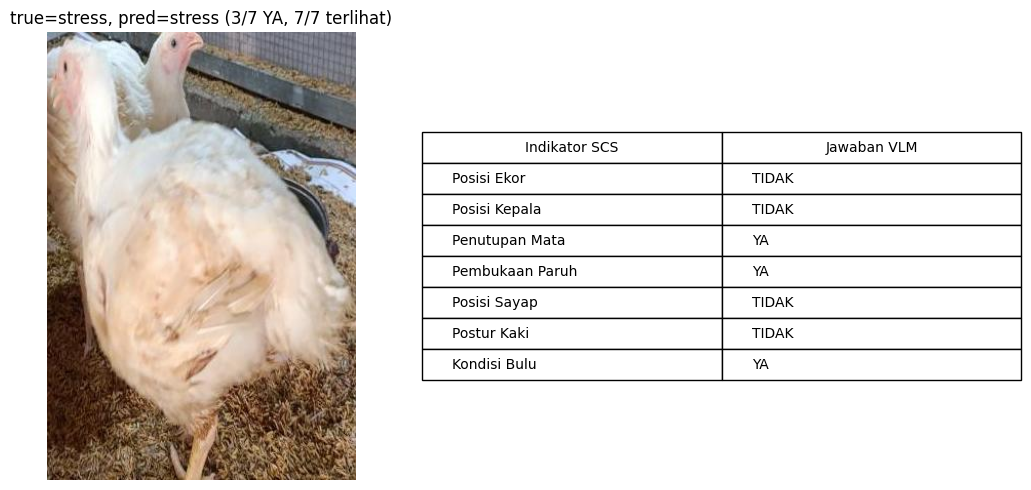

In [53]:
def show_indicator_breakdown(image_path, result, title_prefix=""):
    fig, (ax_img, ax_table) = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [1, 1.2]})

    ax_img.imshow(Image.open(image_path))
    ax_img.axis("off")
    ax_img.set_title(f"{title_prefix}pred={result['label']} ({result['total_ya']}/7 YA, {result['visible_count']}/7 terlihat)")

    ax_table.axis("off")
    rows = [[ind["name"], result["indicators"][ind["key"]]] for ind in SCS_INDICATORS]
    table = ax_table.table(cellText=rows, colLabels=["Indikator SCS", "Jawaban VLM"],
                            loc="center", cellLoc="left")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.6)
    plt.tight_layout()
    plt.show()


# Ambil satu contoh test per kelas, tampilkan breakdown untuk konfigurasi terbaik
best_key = "fine_tuned" if best_config == vlm_experiments["fine_tuned"]["label"] else "zero_shot"
best_records = raw_predictions.get(best_key)

if best_records is not None and not best_records.empty:
    for cls in class_to_id:
        subset = best_records[best_records["true_label"] == cls]
        if subset.empty:
            continue
        row = subset.iloc[0]
        show_indicator_breakdown(row["image_path"], row.to_dict(), title_prefix=f"true={cls}, ")


## Catatan lanjutan

- Evaluasi di atas dipakai untuk **memilih** konfigurasi paling menjanjikan (zero-shot vs fine-tuned VLM),
  bukan hasil final — sesuai catatan *Justifikasi* pada dokumen Workflow Change Request, "perlu validasi
  lebih lanjut ke kasus poultry".
- `n_parse_error` pada tabel evaluasi lanjutan (bagian 5) penting dipantau: kalau tinggi, berarti VLM sering
  tidak menjawab dalam format JSON yang diminta — pertimbangkan menurunkan `max_new_tokens`, memperkuat
  instruksi format pada prompt, atau mengganti `VLM_MODEL_NAME` ke model yang lebih taat instruksi.
- Fine-tuning (LoRA) saat ini hanya mensupervisi label akhir (lihat catatan di Bagian 2: Modelling).
  Begitu tersedia anotasi per-indikator (checklist SCS diisi manual oleh annotator, bukan cuma label akhir),
  evaluasi bisa diperluas untuk mengukur akurasi VLM **per indikator**, bukan cuma pada label biner akhir.
- Validasi eksternal (citra dari kandang mitra yang berbeda dari data pelatihan) tetap perlu dilakukan sebelum
  model dipakai untuk pengambilan keputusan operasional, konsisten dengan `Kesimpulan` pada dokumen Workflow
  Change Request.